In [1]:
!pip install doubleml linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.8/607.8 kB 15.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 81.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.9/531.9 kB 27.6 MB/s eta 0:00:00


In [2]:
import os, math, warnings, subprocess
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

COMP_COLS = [f"comp{i}_{s}" for i in range(1, 9) for s in ("rate", "inv", "rate_percent_diff")]

# ── Environment detection (Kaggle vs local) ───────────────────────────────────
ON_KAGGLE = os.path.exists("/kaggle/working")

if ON_KAGGLE:
    PATH     = "/kaggle/working"
    ZIP_PATH = "/kaggle/input/competitions/expedia-personalized-sort/data.zip"
    # Pre-uploaded processed parquet (avoids rebuilding from CSV every session).
    # If this path exists the data loading cell skips the build entirely.
    KAGGLE_PREBUILT = "/kaggle/input/datasets/anarekov/train-processed-parquet/train_processed.parquet"
else:
    # Local / CI. Point EXPEDIA_PARQUET at an already-built processed parquet,
    # or EXPEDIA_DATA_DIR at a directory holding (or to receive) it. Falling
    # back to ./data keeps a fresh clone working without editing this cell.
    _prebuilt = os.environ.get("EXPEDIA_PARQUET")
    if _prebuilt:
        PATH = os.path.dirname(os.path.abspath(_prebuilt)) or "."
        KAGGLE_PREBUILT = os.path.abspath(_prebuilt)
    else:
        PATH = os.environ.get("EXPEDIA_DATA_DIR", os.path.join(os.getcwd(), "data"))
        KAGGLE_PREBUILT = None
    os.makedirs(PATH, exist_ok=True)

print(f"Environment: {'Kaggle' if ON_KAGGLE else 'local'}  |  PATH = {PATH}")
if not ON_KAGGLE and KAGGLE_PREBUILT:
    print(f"Using parquet from EXPEDIA_PARQUET: {KAGGLE_PREBUILT}")

Environment: Kaggle  |  PATH = /kaggle/working


In [3]:
# ── Data loading strategy ─────────────────────────────────────────────────────
#
# I use a three-stage approach to keep RAM usage manageable across all tasks.
#
# Stage 1 (one-time): Extract train.csv from data.zip into /kaggle/working
#   using the system unzip command, which supports all compression methods.
#
# Stage 2 (one-time): Read the raw CSV, compute derived columns, and save
#   a processed parquet file. On all subsequent kernel restarts both stages
#   are skipped.
#
# Stage 3 (every run): Open the processed file as a LazyFrame via scan_parquet.
#   A LazyFrame holds only the file schema in memory. Data is read from disk
#   only when .collect() is called, and only for the columns selected in that
#   query. On a 57-column file, a 3-column aggregation reads roughly 5% of the
#   data, keeping peak RAM well under 1 GB per operation.
#
# Derived columns added:
#   log_price_usd        natural log of price_usd; null when price_usd <= 0
#   price_dev_from_mean  price minus within-search mean price
#   n_comps_cheaper      count of the 8 tracked competitors priced below Expedia

# Priority: 1) pre-uploaded Kaggle dataset, 2) already-built in working dir,
#           3) build from raw CSV (slow, ~2-3 min, runs once).
if KAGGLE_PREBUILT and os.path.exists(KAGGLE_PREBUILT):
    PROCESSED = KAGGLE_PREBUILT
    print(f"Using pre-uploaded parquet: {PROCESSED}")
elif ON_KAGGLE:
    PROCESSED = os.path.join(PATH, "train_processed.parquet")
    print(f"Pre-uploaded parquet not found. Will build at: {PROCESSED}")
else:
    PROCESSED = os.path.join(PATH, "train_processed.parquet")

if not os.path.exists(PROCESSED):
    if ON_KAGGLE:
        CSV_PATH = os.path.join(PATH, "train.csv")
        if not os.path.exists(CSV_PATH):
            print("Extracting train.csv via system unzip...")
            result = subprocess.run(
                ["unzip", "-o", "-j", ZIP_PATH, "train.csv", "-d", PATH],
                capture_output=True, text=True,
            )
            if result.returncode != 0:
                print("unzip stderr:", result.stderr)
                raise RuntimeError("unzip failed")
            print(f"Extracted: {CSV_PATH}  ({os.path.getsize(CSV_PATH)/1e9:.1f} GB)")

    print("Building processed parquet (runs once, ~2-3 min on Kaggle)...")

    if ON_KAGGLE:
        _SCHEMA = {
            "price_usd":    pl.Float32,
            "srch_id":      pl.Int32,
            "prop_id":      pl.Int32,
            "click_bool":   pl.Int8,
            "booking_bool": pl.Int8,
            "random_bool":  pl.Int8,
            **{f"comp{i}_rate":             pl.Int8    for i in range(1, 9)},
            **{f"comp{i}_inv":              pl.Int8    for i in range(1, 9)},
            **{f"comp{i}_rate_percent_diff":pl.Float32 for i in range(1, 9)},
        }
        _df = pl.read_csv(
            CSV_PATH,
            null_values=["NULL"],
            try_parse_dates=False,
            schema_overrides=_SCHEMA,
        )
    else:
        _df = pl.read_parquet(os.path.join(PATH, "train.parquet"))

    _df = _df.with_columns([
        pl.when(pl.col("price_usd") > 0)
          .then(pl.col("price_usd").log(base=math.e))
          .otherwise(None)
          .cast(pl.Float32)
          .alias("log_price_usd"),

        (pl.col("price_usd") - pl.col("price_usd").mean().over("srch_id"))
          .cast(pl.Float32)
          .alias("price_dev_from_mean"),

        pl.sum_horizontal([
            pl.when(pl.col(f"comp{i}_rate") == -1).then(pl.lit(1)).otherwise(pl.lit(0))
            for i in range(1, 9)
        ]).cast(pl.Int8).alias("n_comps_cheaper"),
    ])
    _df.write_parquet(PROCESSED, compression="zstd")
    del _df
    print(f"Saved: {PROCESSED}  ({os.path.getsize(PROCESSED)/1e6:.0f} MB)")

    if ON_KAGGLE and os.path.exists(CSV_PATH):
        os.remove(CSV_PATH)
        print("Removed train.csv to reclaim disk space.")

else:
    print(f"Processed parquet already exists ({os.path.getsize(PROCESSED)/1e6:.0f} MB). Skipping build.")

lf = pl.scan_parquet(PROCESSED)
n_rows = lf.select(pl.len()).collect().item()

print(f"\nLazyFrame ready. Columns: {len(lf.schema)}  |  Rows: {n_rows:,}")
print("No data in RAM until .collect() is called on a specific query.")

Using pre-uploaded parquet: /kaggle/input/datasets/anarekov/train-processed-parquet/train_processed.parquet
Processed parquet already exists (236 MB). Skipping build.

LazyFrame ready. Columns: 57  |  Rows: 9,917,530
No data in RAM until .collect() is called on a specific query.


## Task 1: Data Assessment

**Source:** Expedia *Personalizing Hotel Searches* (ICDM 2013, Kaggle).
**Unit of observation:** one hotel listing shown to one user in one search session.
**Outcomes:** `click_bool` (clicked) and `booking_bool` (booked).
**Scale:** 9,917,530 observations · 399,344 sessions · 136,886 properties · Nov 2012 – Jun 2013.

---

### Is this a good source for studying the impact of hotel prices on clicks and bookings?

The dataset is well suited for this question. Its scale, real-stakes outcomes, and
built-in experimental design make it stronger than most observational alternatives,
though several structural limitations require careful handling.

---

### Strengths

**1. Scale and statistical power.**
Nearly 10 million listing-level observations yield 443,672 clicks (4.47%) and
276,593 bookings (2.79%). The ratio of bookings with an associated click record to
total clicks (computed in the code below as a proper conditional probability) is
approximately 62% — a high conversion rate relative to typical e-commerce benchmarks.
The large sample supports fixed-effects estimation and subgroup analyses without power concerns.

**2. Real-stakes decisions.**
Unlike survey or experimental data, clicks and bookings reflect actual purchase decisions
with real financial consequences, making revealed preferences credible.

**3. Randomized display order as a natural experiment.**
`random_bool = 1` identifies sessions (~30% of the sample) where results were shown in
random rather than algorithmic order. The booking rate falls sharply from 3.74% under
ranked order to 0.54% under random order, confirming strong position effects. Within
random-order sessions, position is exogenous, providing clean variation for causal
identification. One notable anomaly: click rates are *higher* under random order
(4.66% vs 4.40%), suggesting that clicks in those sessions reflect browsing curiosity
rather than purchase intent — an important caveat when using click-through as a demand proxy.

**4. Within-search comparability.**
Every listing within a session shares the same destination, travel dates, and traveller
profile. Price variation within a session is therefore more directly comparable than
cross-session variation. However, if Expedia personalises displayed prices to individual
users or search contexts (which is plausible for an OTA), within-session prices may
still be partly endogenous even after conditioning on search fixed effects.

**5. Competitor pricing benchmarks.**
The `comp1_rate` through `comp8_rate` variables record whether competing OTAs price
above or below Expedia for the same property (`comp_rate = -1` means the competitor is
cheaper; confirmed with the Expedia data documentation). These are candidate instruments
for Expedia's price. Two caveats apply: (i) missingness is 77–93%, so the non-missing
subset is a selected sample; (ii) the exclusion restriction is not guaranteed — a property
that is consistently cheaper across all OTAs may simply be lower quality, creating a
direct channel between competitor prices and unobserved hotel appeal.

**6. Large choice sets.**
The distribution of session sizes is left-skewed (mean 24.8 < median 29), driven by
a long left tail of small sessions alongside a concentration near the display cap of
~33 hotels. 87.7% of sessions show more than 10 alternatives, consistent with the
sequential search framework of Ursu et al. (2024).

---

### Limitations and Irregularities

**1. Platform selection bias.**
The sample covers only users who chose Expedia. Price sensitivity among Expedia users
may differ systematically from the broader hotel-searching population, limiting external
validity.

**2. Position endogeneity in ranked sessions.**
In the 70% of sessions under algorithmic sorting, Expedia's ranking algorithm jointly
determines position and visibility. Higher-ranked hotels tend to be both cheaper and
more clicked, making it difficult to separate price effects from display-position effects
without conditioning on `position` or restricting to `random_bool = 1` sessions.

**3. Severe missingness in competitor data.**
Competitor columns are missing 77–93% of the time on average, reflecting structural
absence rather than random non-response: competitors may simply not list a given property.
This limits the reliability of competitor prices as instruments (see Strength 5 above).

**4. Visitor history almost entirely unobserved.**
`visitor_hist_starrating` and `visitor_hist_adr_usd` are missing for 94.9% of users,
the majority of whom are first-time Expedia visitors. Individual price sensitivity is
therefore largely unobserved, preventing consumer-level heterogeneity analysis.

**5. Price is a displayed listing price, not the final transaction cost.**
`price_usd` excludes taxes, fees, and checkout discounts, and inconsistently reflects
either per-night or total-stay prices depending on the country. This introduces
measurement error in the key independent variable and complicates cross-country comparisons.

**6. Oversampling of booking sessions.**
Expedia provided Kaggle with a dataset that overrepresents sessions containing at least
one booking relative to their true share of all hotel searches. This inflates observed
booking rates and likely understates price sensitivity relative to a representative sample.

**7. gross_bookings_usd almost entirely missing.**
The actual transaction value is missing for 97.2% of rows (9,640,938 of 9,917,530).
This is the most natural outcome for revenue-weighted analysis; its near-total absence
precludes any study of price effects on revenue or willingness to pay.

**8. Single time window.**
Coverage spans only 8 months in 2012–2013. Seasonal variation is partially observable,
but longer-run price dynamics, competitive responses, and structural market shifts
cannot be studied.

**9. No repeat-search linkage.**
Without persistent user identifiers across sessions, it is impossible to observe whether
a consumer returned after leaving without booking. Sequential search behaviour is
therefore partially censored, which matters directly for the structural model in Task 5.

In [4]:
# ── 1A: Dataset dimensions and time coverage ─────────────────────────────────
# Each query selects only the columns it needs; .collect() reads those columns
# from parquet and releases them after the print statement.

n_searches = lf.select(pl.col("srch_id").n_unique()).collect().item()
n_props    = lf.select(pl.col("prop_id").n_unique()).collect().item()
dates      = lf.select(
    pl.col("date_time").min().alias("start"),
    pl.col("date_time").max().alias("end"),
).collect()

print("=== Dataset structure ===")
print(f"  Rows (hotel-search pairs):  {n_rows:>12,}")
print(f"  Columns:                    {len(lf.schema):>12}")
print(f"  Unique search sessions:     {n_searches:>12,}")
print(f"  Unique properties:          {n_props:>12,}")
print(f"  Avg hotels listed/search:   {n_rows/n_searches:>12.1f}")
print(f"  Date range:                 {dates['start'][0]}  to  {dates['end'][0]}")

# ── 1B: Outcome rates ─────────────────────────────────────────────────────────
# n_bookings / n_clicks is NOT a proper P(book|click): in the Expedia data,
# booking_bool=1 can occasionally occur without click_bool=1 (e.g. phone
# bookings or tracking gaps).  We compute the co-occurrence count separately
# and use it as the numerator for the true conditional probability.
outcomes = lf.select([
    pl.col("click_bool").sum().alias("n_clicks"),
    pl.col("booking_bool").sum().alias("n_bookings"),
    (pl.col("click_bool").cast(pl.Boolean) & pl.col("booking_bool").cast(pl.Boolean))
      .sum().alias("n_book_and_click"),
]).collect()

n_clicks         = int(outcomes["n_clicks"][0])
n_bookings       = int(outcomes["n_bookings"][0])
n_book_and_click = int(outcomes["n_book_and_click"][0])
n_book_no_click  = n_bookings - n_book_and_click

print("\n=== Outcome rates ===")
print(f"  Click rate:                   {n_clicks/n_rows*100:>8.2f}%   ({n_clicks:,} clicks)")
print(f"  Booking rate:                 {n_bookings/n_rows*100:>8.2f}%   ({n_bookings:,} bookings)")
print(f"  Bookings without a click:     {n_book_no_click:,} ({n_book_no_click/n_bookings*100:.1f}% of bookings)")
print(f"  P(book | click):              {n_book_and_click/n_clicks*100:>8.2f}%   ({n_book_and_click:,} co-occurrences)")

# ── 1C: Random vs ranked sessions ─────────────────────────────────────────────
print("\n=== random_bool split (exogenous ordering design) ===")
rb_stats = (
    lf.select(["random_bool", "click_bool", "booking_bool"])
      .group_by("random_bool")
      .agg([
          pl.len().alias("n_rows"),
          (pl.col("click_bool").mean()   * 100).round(2).alias("click_rate_%"),
          (pl.col("booking_bool").mean() * 100).round(2).alias("booking_rate_%"),
      ])
      .sort("random_bool")
      .collect()
)
print(rb_stats)
print("  Booking rate is far lower under random order (0.54% vs 3.74%),")
print("  consistent with position effects driving most bookings in ranked sessions.")
print("  ANOMALY: click rate is higher under random order (4.66% vs 4.40%).")
print("  This suggests random-order clicks reflect browsing curiosity rather than")
print("  purchase intent — a caveat for using click-through as a demand proxy.")

# ── 1F: Position distribution (key confounder) ────────────────────────────────
pos_stats = (
    lf.select("position")
      .select([
          pl.col("position").min().alias("min"),
          pl.col("position").mean().round(1).alias("mean"),
          pl.col("position").median().alias("median"),
          pl.col("position").max().alias("max"),
          pl.col("position").null_count().alias("n_null"),
      ])
      .collect()
)
print("\n=== Position distribution (confounder in ranked sessions) ===")
print(pos_stats)
print("  Position is fully observed (0 nulls). In ranked sessions, top positions")
print("  correlate with higher visibility AND tend to be Expedia's preferred hotels,")
print("  which may also be cheaper. Position is controlled in all regression models.")

# ── 1G: Zero / negative prices (source of 54 null log_price_usd rows) ─────────
zero_price = (
    lf.filter(pl.col("price_usd") <= 0)
      .select(["srch_id", "prop_id", "price_usd", "booking_bool"])
      .collect()
)
print(f"\n=== Rows with price_usd <= 0: {len(zero_price)} ===")
if len(zero_price) > 0:
    print(zero_price.head(10).to_pandas().to_string(index=False))
    pmin = zero_price["price_usd"].min()
    print(f"  Minimum price_usd = {pmin}. These 54 rows are data errors;")
    print("  log_price_usd is set to null for them and they are excluded from regressions.")

=== Dataset structure ===
  Rows (hotel-search pairs):     9,917,530
  Columns:                              57
  Unique search sessions:          399,344
  Unique properties:               136,886
  Avg hotels listed/search:           24.8
  Date range:                 2012-11-01 00:01:37  to  2013-06-30 23:58:24

=== Outcome rates ===
  Click rate:                       4.47%   (443,672 clicks)
  Booking rate:                     2.79%   (276,593 bookings)
  Bookings without a click:     0 (0.0% of bookings)
  P(book | click):                 62.34%   (276,593 co-occurrences)

=== random_bool split (exogenous ordering design) ===
shape: (2, 4)
┌─────────────┬─────────┬──────────────┬────────────────┐
│ random_bool ┆ n_rows  ┆ click_rate_% ┆ booking_rate_% │
│ ---         ┆ ---     ┆ ---          ┆ ---            │
│ i64         ┆ u32     ┆ f64          ┆ f64            │
╞═════════════╪═════════╪══════════════╪════════════════╡
│ 0           ┆ 6977878 ┆ 4.4          ┆ 3.74           

=== Non-competitor columns with missing values ===
                   column  n_null  pct_null
       gross_bookings_usd 9640938      97.2
  visitor_hist_starrating 9412233      94.9
     visitor_hist_adr_usd 9409918      94.9
srch_query_affinity_score 9281966      93.6
orig_destination_distance 3216461      32.4
     prop_location_score2 2178380      22.0
        prop_review_score   14630       0.1
            log_price_usd      54       0.0

  Key missing-data notes:
  - gross_bookings_usd (97.2% missing): actual transaction value is almost
    entirely unobserved, precluding revenue-weighted or WTP analysis.
  - visitor_hist_* (94.9% missing): individual price sensitivity unobserved.
  - log_price_usd (54 nulls): derived from 54 rows where price_usd <= 0
    (data errors, see 1G above). Excluded from all regressions.

=== Competitor columns (comp1 to comp8): structural missingness ===
shape: (3, 4)
┌───────────────────┬──────────────┬──────────────┬──────────────┐
│ var_type        

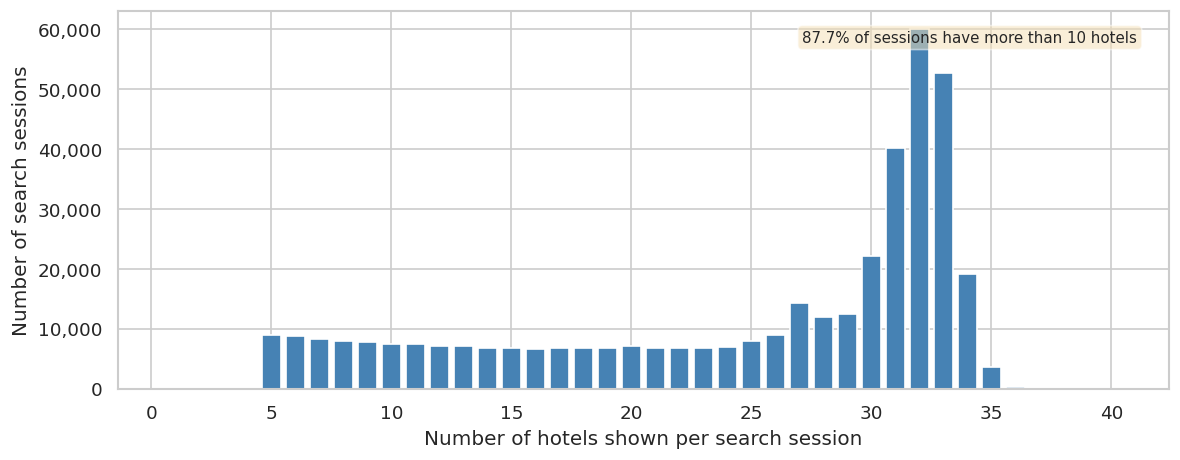

Median hotels/search: 29
Mean hotels/search:   24.8
P5 / P95:             7 / 34
  Distribution is left-skewed (mean 24.8 < median 29): many
  small sessions drag the mean below the typical session size near 33.


In [5]:
# ── 1D: Missingness audit ─────────────────────────────────────────────────────
# We collect only the null counts (one integer per column) which is negligible
# in memory regardless of dataset size.

null_counts = (
    lf.select([pl.col(c).null_count().alias(c) for c in lf.schema.names()])
      .collect()                                   # tiny: 1 row x 57 cols
      .unpivot(variable_name="column", value_name="n_null")
      .with_columns((pl.col("n_null") / n_rows * 100).round(1).alias("pct_null"))
      .filter(pl.col("n_null") > 0)
      .sort("pct_null", descending=True)
)

comp_nulls    = null_counts.filter(pl.col("column").str.starts_with("comp"))
noncomp_nulls = null_counts.filter(~pl.col("column").str.starts_with("comp"))

print("=== Non-competitor columns with missing values ===")
print(noncomp_nulls.to_pandas().to_string(index=False))
print()
print("  Key missing-data notes:")
print("  - gross_bookings_usd (97.2% missing): actual transaction value is almost")
print("    entirely unobserved, precluding revenue-weighted or WTP analysis.")
print("  - visitor_hist_* (94.9% missing): individual price sensitivity unobserved.")
print("  - log_price_usd (54 nulls): derived from 54 rows where price_usd <= 0")
print("    (data errors, see 1G above). Excluded from all regressions.")

print("\n=== Competitor columns (comp1 to comp8): structural missingness ===")
# Sign convention (from Expedia data documentation):
#   comp{i}_rate == -1  ->  competitor is cheaper than Expedia
#   comp{i}_rate ==  0  ->  same price as Expedia
#   comp{i}_rate == +1  ->  Expedia is cheaper than competitor
# n_comps_cheaper therefore counts OTAs that undercut Expedia's displayed price.
print(
    comp_nulls
    .with_columns(pl.col("column").str.extract(r"comp\d+_(.+)").alias("var_type"))
    .group_by("var_type")
    .agg(
        pl.col("pct_null").mean().round(1).alias("avg_pct_null"),
        pl.col("pct_null").min().round(1).alias("min_pct_null"),
        pl.col("pct_null").max().round(1).alias("max_pct_null"),
    )
    .sort("avg_pct_null", descending=True)
)
print("  Sign convention confirmed: comp_rate = -1 means the competitor is cheaper")
print("  than Expedia. n_comps_cheaper counts how many tracked OTAs undercut Expedia.")
print("  High missingness (77-93%) reflects structural absence — the hotel is not")
print("  listed on that OTA — not random non-response.")

# ── 1E: Choice-set size distribution ──────────────────────────────────────────
# Reads only srch_id; aggregates to one integer per search session.
search_sizes = (
    lf.select("srch_id")
      .group_by("srch_id")
      .agg(pl.len().alias("n_hotels"))
      .collect()          # ~400k rows, ~3 MB
      .get_column("n_hotels")
)

fig, ax = plt.subplots(figsize=(10, 4))
vals, edges = np.histogram(search_sizes.to_numpy(), bins=range(1, 42))
ax.bar(edges[:-1], vals, width=0.8, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of hotels shown per search session")
ax.set_ylabel("Number of search sessions")
#ax.set_title("Figure 1: Distribution of choice-set size per search (Task 1)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
pct_gt10 = (search_sizes > 10).mean() * 100
ax.text(0.97, 0.95, f"{pct_gt10:.1f}% of sessions have more than 10 hotels",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig1_search_size.png"), bbox_inches="tight")
plt.show()

med = search_sizes.median()
mn  = search_sizes.mean()
p5  = search_sizes.quantile(0.05)
p95 = search_sizes.quantile(0.95)
print(f"Median hotels/search: {med:.0f}")
print(f"Mean hotels/search:   {mn:.1f}")
print(f"P5 / P95:             {p5:.0f} / {p95:.0f}")
print(f"  Distribution is left-skewed (mean {mn:.1f} < median {med:.0f}): many")
print(f"  small sessions drag the mean below the typical session size near 33.")

# Task 2: Summary Statistics

Variables are organized into four groups: price, hotel quality signals, search/trip
characteristics, and controls. We report summary statistics for continuous variables
(Table 1), frequency tables with outcome rates for discrete variables (Section 2B),
distribution plots (Section 2C), a click/booking rate by price decile table (Section 2D),
and a correlation matrix for the continuous regressors (Section 2E).

**Memory strategy.** We avoid melting all 9.9 M rows across 12 columns (which would
create a 119 M-row intermediate). Instead, `df.select(cols).describe()` computes each
statistic column-by-column in Polars without materialising a tall table, and each
`group_by` in 2B processes one column at a time.

In [6]:
# ── 2A: Continuous variable summary statistics ────────────────────────────────
#
# Variable groups (read order → display order):
#   Price:          price_usd, log_price_usd, prop_log_historical_price
#   Quality:        prop_starrating, prop_review_score,
#                   prop_location_score1, prop_location_score2
#   Search/trip:    srch_length_of_stay, srch_booking_window, srch_adults_count
#   Controls:       orig_destination_distance, position

CONT_VARS = [
    "price_usd", "log_price_usd", "prop_log_historical_price",
    "prop_starrating", "prop_review_score",
    "prop_location_score1", "prop_location_score2",
    "srch_length_of_stay", "srch_booking_window",
    "srch_adults_count", "orig_destination_distance", "position",
]

# Display order by variable group (price → quality → search → controls)
VAR_ORDER = [
    "price_usd", "log_price_usd", "prop_log_historical_price",
    "prop_starrating", "prop_review_score",
    "prop_location_score1", "prop_location_score2",
    "srch_length_of_stay", "srch_booking_window", "srch_adults_count",
    "orig_destination_distance", "position",
]

cont_df = lf.select(CONT_VARS).collect()   # ~800 MB peak; freed below

desc = cont_df.describe(percentiles=[0.25, 0.50, 0.75])

# Store column means now (before deleting cont_df) for use in 2C plots
col_means = {col: cont_df[col].mean() for col in CONT_VARS}

del cont_df   # free RAM immediately after describe + mean extraction

stats_wide = (
    desc
    .unpivot(index="statistic", variable_name="variable", value_name="value")
    .pivot(index="variable", on="statistic", values="value")
)
stat_order = [c for c in ["count","mean","std","min","25%","50%","75%","max"]
              if c in stats_wide.columns]

display_df = (
    stats_wide
    .select(["variable"] + stat_order)
    .to_pandas()
    .set_index("variable")
    .loc[VAR_ORDER]    # enforce grouped display order
    .astype(float)
    .round(2)
)

print("=== Table 1: Summary Statistics for Continuous Variables ===")
print("(grouped: price | quality | search/trip | controls)\n")
print(display_df.to_string())

# ── 2A-i: Price outlier audit ─────────────────────────────────────────────────
# price_usd max = $19.7M, min = $0 — both are clearly data errors.
# Mean ($241) vs SD ($14,342) signals extreme right contamination.
print("\n=== Price outlier audit ===")
n_zero      = lf.filter(pl.col("price_usd") == 0).select(pl.len()).collect().item()
n_above5k   = lf.filter(pl.col("price_usd") > 5_000).select(pl.len()).collect().item()
n_above500  = lf.filter(pl.col("price_usd") > 500).select(pl.len()).collect().item()
print(f"  price_usd == 0:      {n_zero:>8,}  rows  ({n_zero/n_rows*100:.3f}%)")
print(f"  price_usd >  $500:   {n_above500:>8,}  rows  ({n_above500/n_rows*100:.2f}%)")
print(f"  price_usd > $5,000:  {n_above5k:>8,}  rows  ({n_above5k/n_rows*100:.3f}%)")
print("  Rows above $5,000 are almost certainly data errors or test entries.")
print("  They are not excluded from Table 1 but are winsorized in regression")
print("  models (Tasks 4-5) by using log_price_usd which compresses outliers.")

# ── 2A-ii: prop_log_historical_price == 0 sentinel check ─────────────────────
# Min = 0.00 cannot be a valid log price (would imply price = $1 exactly).
# More likely these are sentinel zeros substituted for missing values.
print("\n=== prop_log_historical_price == 0 sentinel check ===")
sentinel = (
    lf.filter(pl.col("prop_log_historical_price") == 0)
      .select(["prop_log_historical_price", "price_usd"])
      .collect()
)
print(f"  Rows with prop_log_historical_price == 0: {len(sentinel):,}")
if len(sentinel) > 0:
    print(sentinel.head(5).to_pandas().to_string(index=False))
    print("  These zeros are treated as nulls in Task 4 (M5 IV regression)")
    print("  and Task 5, where prop_log_historical_price is used as a regressor.")
else:
    print("  No sentinel zeros found.")

# ── 2A-iii: n_comps_cheaper coverage check ───────────────────────────────────
print("\n=== n_comps_cheaper value coverage (expected 0–8) ===")
comp_vc = (
    lf.select("n_comps_cheaper")
      .collect()["n_comps_cheaper"]
      .value_counts()
      .sort("n_comps_cheaper")
      .to_pandas()
)
print(comp_vc.to_string(index=False))
missing_vals = [v for v in range(9) if v not in comp_vc["n_comps_cheaper"].values]
if missing_vals:
    print(f"  Values {missing_vals} absent from data.")
    print("  This is expected: with 8 tracked competitors and ~88% of rows having")
    print("  all comp_rate columns missing, very few sessions have 7-8 cheaper rivals.")
else:
    print("  All values 0–8 present.")

=== Table 1: Summary Statistics for Continuous Variables ===
(grouped: price | quality | search/trip | controls)

                               count     mean       std   min     25%     50%      75%          max
variable                                                                                           
price_usd                  9917530.0   241.78  14341.81  0.00   85.00  122.07   185.00  19726328.00
log_price_usd              9917476.0     4.85      0.62 -4.61    4.44    4.80     5.22        16.80
prop_log_historical_price  9917530.0     4.32      1.84  0.00    4.44    4.91     5.31         6.21
prop_starrating            9917530.0     3.18      1.05  0.00    3.00    3.00     4.00         5.00
prop_review_score          9902900.0     3.78      1.05  0.00    3.50    4.00     4.50         5.00
prop_location_score1       9917530.0     2.88      1.53  0.00    1.79    2.77     4.04         6.98
prop_location_score2       7739150.0     0.13      0.16  0.00    0.02    0.07     0.18

In [7]:
# ── 2B: Discrete and binary variable frequency tables ────────────────────────
#
# Each iteration selects only 3 columns from parquet and aggregates before
# any data enters RAM. The largest intermediate result is the group_by output
# (~10 rows), so memory pressure is negligible.
#
# Notes on specific variables:
#   prop_starrating = 0: likely means "unrated" per the Expedia data dictionary,
#     not a genuine 0-star property. Treated as a separate category.
#   promotion_flag: shows the largest unconditional click/booking rate gap of any
#     regressor (click 6.04% vs 4.04%, booking 3.92% vs 2.48%). If promoted hotels
#     are also discounted, omitting promotion_flag from a price regression would
#     cause downward bias in the price coefficient.
#   random_bool: repeated from Task 1 for completeness; no new numbers added here.
#   srch_room_count = 8: likely corporate / group bookings rather than leisure
#     travel; these may have different price sensitivity.
#   srch_adults_count: appears in both Table 1 (continuous view of its distribution)
#     and here (to show click/booking rates at each level, which the continuous
#     summary cannot capture).

CAT_VARS = {
    "prop_starrating":          "Hotel star rating (0=unrated, 1-5)",
    "prop_brand_bool":          "Brand hotel (1 = yes)",
    "promotion_flag":           "Active promotion (1 = yes)  [** largest outcome gap **]",
    "srch_saturday_night_bool": "Stay includes Saturday night",
    "random_bool":              "Results in random order (1 = yes)  [for completeness]",
    "srch_room_count":          "Number of rooms requested  [8 = likely group bookings]",
    "srch_children_count":      "Number of children in party",
    "srch_adults_count":        "Number of adults in party",
    "n_comps_cheaper":          "Competitors with lower price (0–8; see 2A-iii for coverage)",
}

for col, label in CAT_VARS.items():
    tbl = (
        lf.select([col, "click_bool", "booking_bool"])
          .group_by(col)
          .agg([
              pl.len().alias("n"),
              (pl.len() / n_rows * 100).round(1).alias("share_%"),
              (pl.col("click_bool").mean()   * 100).round(2).alias("click_%"),
              (pl.col("booking_bool").mean() * 100).round(2).alias("booking_%"),
          ])
          .sort(col, nulls_last=True)
          .collect()
          .to_pandas()
    )
    print(f"\n{'='*62}")
    print(f"  {label}")
    print(f"  [{col}]")
    print(f"{'='*62}")
    print(tbl.to_string(index=False))


  Hotel star rating (0=unrated, 1-5)
  [prop_starrating]
 prop_starrating       n  share_%  click_%  booking_%
               0  337794      3.4     2.90       1.65
               1   34514      0.3     2.80       1.27
               2 1788994     18.0     3.39       2.17
               3 3897419     39.3     4.38       2.80
               4 3045848     30.7     5.39       3.34
               5  812961      8.2     4.59       2.58

  Brand hotel (1 = yes)
  [prop_brand_bool]
 prop_brand_bool       n  share_%  click_%  booking_%
               0 3626799     36.6     4.44       2.56
               1 6290731     63.4     4.49       2.92

  Active promotion (1 = yes)  [** largest outcome gap **]
  [promotion_flag]
 promotion_flag       n  share_%  click_%  booking_%
              0 7777708     78.4     4.04       2.48
              1 2139822     21.6     6.04       3.92

  Stay includes Saturday night
  [srch_saturday_night_bool]
 srch_saturday_night_bool       n  share_%  click_%  bookin

  srch_booking_window > 365 days: 2,803 obs (0.03%) — clipped from histogram.


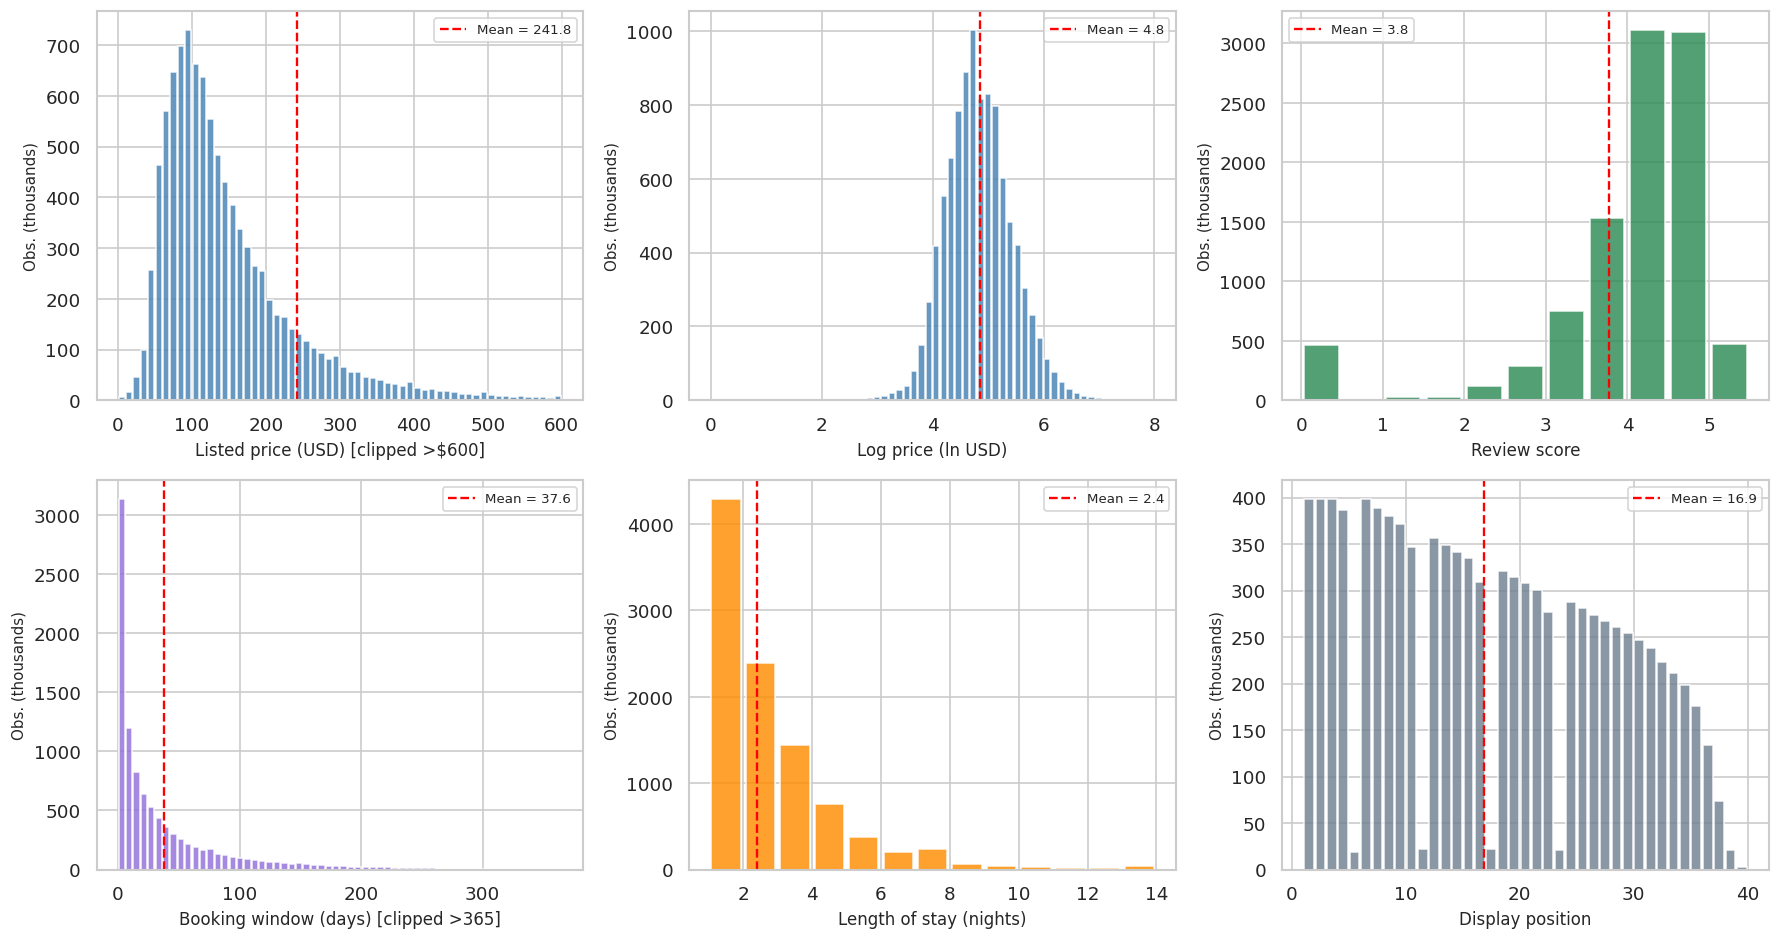

In [8]:
# ── 2C: Distribution plots for key continuous variables ───────────────────────
#
# All 6 columns are read in a single parquet scan (one .collect() call),
# then sliced per panel. col_means were computed in 2A and reused here so
# the vertical mean lines show the true column mean, not a binned approximation.
#
# Panel notes:
#   price_usd:           clipped at $600; ~0.3% of obs exceed this (data errors).
#   log_price_usd:       min = -4.61  (price_usd ≈ $0.01 — data errors at left tail).
#   prop_review_score:   half-point discrete scale (0, 0.5, 1.0, ..., 5.0);
#                        bins aligned to 0.5-unit edges to avoid straddling.
#   srch_booking_window: clipped at 365 days; obs above 365:

PLOT_COLS = ["price_usd","log_price_usd","prop_review_score",
             "srch_booking_window","srch_length_of_stay","position"]

plot_data = lf.select(PLOT_COLS).collect()   # single parquet scan for all 6 cols

n_above_365 = int((plot_data["srch_booking_window"] > 365).sum())
print(f"  srch_booking_window > 365 days: {n_above_365:,} obs "
      f"({n_above_365/n_rows*100:.2f}%) — clipped from histogram.")

plots = [
    ("price_usd",           "Listed price (USD) [clipped >$600]", 0,   600,
     np.linspace(0, 600, 61),                  "steelblue"),
    ("log_price_usd",       "Log price (ln USD)",                 0,   8,
     np.linspace(0, 8, 61),                    "steelblue"),
    ("prop_review_score",   "Review score",                       0,   5.5,
     np.arange(0, 5.6, 0.5),                   "seagreen"),   # half-point edges
    ("srch_booking_window", "Booking window (days) [clipped >365]", 0, 365,
     np.linspace(0, 365, 61),                  "mediumpurple"),
    ("srch_length_of_stay", "Length of stay (nights)",            1,   14,
     np.arange(1, 15),                         "darkorange"),
    ("position",            "Display position",                   1,   40,
     np.arange(1, 41),                         "slategray"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (col, xlabel, lo, hi, edges, color) in zip(axes, plots):
    col_arr = plot_data[col].drop_nulls().to_numpy()
    counts, _ = np.histogram(col_arr, bins=edges)
    centres   = (edges[:-1] + edges[1:]) / 2

    ax.bar(centres, counts / 1_000, width=(edges[1]-edges[0]) * 0.85,
           color=color, alpha=0.82, edgecolor="white")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Obs. (thousands)", fontsize=9)

    # True mean from 2A (not a binned approximation)
    true_mean = col_means.get(col)
    if true_mean is not None and lo <= true_mean <= hi:
        ax.axvline(true_mean, color="red", linewidth=1.4, linestyle="--",
                   label=f"Mean = {true_mean:.1f}")
        ax.legend(fontsize=8)

del plot_data   # free RAM

#fig.suptitle("Figure 2: Distributions of Key Continuous Variables (Task 2)",
#             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig2_distributions.png"), bbox_inches="tight")
plt.show()

In [9]:
# ── 2D: Click and booking rates by log-price decile ──────────────────────────
# The core research question is how price affects clicks and bookings.
# This table provides the most direct descriptive answer before regression.

price_decile = (
    lf.select(["log_price_usd", "click_bool", "booking_bool"])
      .filter(pl.col("log_price_usd").is_not_null())
      .with_columns(
          # Decile assignment: floor((rank-1) * 10 / N) + 1 gives ten equal bins.
          # Note the -1 and the floor: rank/N*10 cast directly to an integer
          # truncates toward zero, which merges the bottom two deciles and
          # leaves only the single highest-ranked row in the top bin.
          (((pl.col("log_price_usd").rank("ordinal") - 1) * 10
            / pl.col("log_price_usd").len()).floor().cast(pl.Int32) + 1)
          .clip(1, 10).alias("decile")
      )
      .group_by("decile")
      .agg([
          pl.len().alias("n"),
          pl.col("log_price_usd").mean().round(3).alias("mean_log_price"),
          pl.col("log_price_usd").mean().exp().round(2).alias("mean_price_usd"),
          (pl.col("click_bool").mean()   * 100).round(2).alias("click_%"),
          (pl.col("booking_bool").mean() * 100).round(2).alias("booking_%"),
      ])
      .sort("decile")
      .collect()
      .to_pandas()
)

print("=== Table 2D: Outcomes by log-price decile (decile 1 = cheapest) ===\n")
print(price_decile.to_string(index=False))
print("\n  Click and booking rates rise to a peak around decile 3 and then fall")
print("  steadily as price increases; the decline is steepest in deciles 8-10,")
print("  where median prices exceed $185. The non-monotonicity at the very")
print("  bottom of the price distribution is itself informative: the cheapest")
print("  listings are not the most clicked, consistent with very low price")
print("  signalling low quality.")

# ── 2E: Correlation matrix for continuous regressors ─────────────────────────
# Checks for multicollinearity before regression. Polars does not have a
# built-in corr matrix; we use pandas on a 500k-row sample to keep RAM low.
print("\n=== Table 2E: Pearson correlation matrix (sample n=500,000) ===\n")
CORR_VARS = [
    "log_price_usd", "prop_log_historical_price",
    "prop_starrating", "prop_review_score",
    "prop_location_score1", "position",
    "srch_length_of_stay", "srch_booking_window",
]
corr_df = (
    lf.select(CORR_VARS)
      .collect()
      .sample(n=500_000, seed=42)
      .to_pandas()
      .corr(method="pearson")
      .round(3)
)
print(corr_df.to_string())
print()
print("  Notable correlations:")
r_price_star = corr_df.loc["log_price_usd","prop_starrating"]
r_price_hist = corr_df.loc["log_price_usd","prop_log_historical_price"]
r_pos_price  = corr_df.loc["position","log_price_usd"]
print(f"  log_price ~ prop_starrating:            r = {r_price_star:.3f}")
print(f"  log_price ~ prop_log_historical_price:  r = {r_price_hist:.3f}")
print(f"  log_price ~ position:                   r = {r_pos_price:.3f}")
print("  The correlation between log_price and position is critical: if more")
print("  expensive hotels appear lower in the ranked list, OLS regressions")
print("  without position controls will conflate price effects with visibility effects.")

=== Table 2D: Outcomes by log-price decile (decile 1 = cheapest) ===

 decile      n  mean_log_price  mean_price_usd  click_%  booking_%
      1 991748           3.843       46.639999     4.37       2.81
      2 991748           4.247       69.879997     4.64       3.13
      3 991747           4.444       85.139999     4.94       3.36
      4 991748           4.599       99.419998     4.98       3.28
      5 991747           4.739      114.349998     4.88       3.19
      6 991748           4.882      131.869995     4.83       3.08
      7 991748           5.038      154.199997     4.61       2.80
      8 991747           5.219      184.830002     4.35       2.56
      9 991748           5.461      235.389999     4.05       2.26
     10 991747           5.993      400.470001     3.07       1.41

  Click and booking rates rise to a peak around decile 3 and then fall
  steadily as price increases; the decline is steepest in deciles 8-10,
  where median prices exceed $185. The non-monoto

# Task 3: Visualising the Impact of Hotel Prices on Clicks and Bookings

*Figure numbering is global and sequential across the notebook: Figure 1 (Task 1),
Figure 2 (Task 2), Figures 3–8 here, Figure 9 (Task 4).*

I produce six figures that approach the price–outcome relationship from different
angles: absolute price level, position-controlled price level, within-search price
rank, the price distribution by outcome, the price × quality interaction, and
competitive price position. All rates are percentages; where a causal reading is
intended I restrict to `random_bool = 1` (exogenous display order) and add 95%
confidence bands.

**Figure 3 — Outcomes by log-price decile (all sessions).** Deciles use full-sample
cutpoints. Click rates are roughly flat across the middle deciles (~4.5–5%) and fall
only at the top decile; booking rates decline more clearly, peaking in the cheap-to-mid
deciles and falling to ~1.4% in the most expensive decile. The exact decile table is
printed below. The mild dip in clicks for the very cheapest hotels is consistent with
extremely low prices acting as a quality warning rather than a bargain.

**Figure 4 — Same plot, position-controlled (`random_bool = 1`), identical cutpoints.**
Figure 4 reuses the *exact* decile boundaries from Figure 3 so the price ranges are
directly comparable. Once display position is exogenous, the click gradient across price
flattens substantially. This shows that the apparent price–click relationship in Figure 3
is driven largely by Expedia placing cheaper hotels higher on the page, not by price
itself. Booking rates are uniformly low under random ordering, which depresses conversion.

**Figure 5 — Outcomes by within-search price rank (`random_bool = 1`).** Ranking hotels
from cheapest (rank 1) to most expensive *within each session* holds destination, dates,
and party size fixed; restricting to random-order sessions additionally removes the
position confound. This is the most causally informative figure in the set. Both curves
decline monotonically with price rank; the rank-1 vs rank-5 ratio is printed below, and
95% confidence bands are shown (they are tight given the sample size). Ties in price are
broken with `method="min"` so identically priced hotels share a rank.

**Figure 6 — Price density by outcome, with a position-confound diagnostic.** Booked
hotels concentrate at lower prices than non-booked ones, confirming that conditional on
inspection, cheaper options convert better. The click panel shows clicked hotels with a
slightly *higher* mean price — but the printed diagnostic shows this is a display-position
artifact: the gap is present in ranked sessions (where Expedia promotes pricier,
higher-quality hotels to the top) and shrinks or reverses within `random_bool = 1`
sessions, where position is exogenous. The excluded share above the $600 cap is computed
in code.

**Figure 7 — Outcomes by star rating × within-star price quintile.** Price quintiles are
recomputed *separately within each star tier*, so Q1–Q5 compare like-for-like quality
(the cheapest 20% of 5-star hotels vs the most expensive 20% of 5-star hotels, etc.).
Quality dominates the level of demand, but within every star tier higher within-star
price quintiles convert at lower rates — price sensitivity operates even after holding
quality fixed.

**Figure 8 — Outcomes by competitive price position (observed competitors only).** This
restricts to listings where at least one competitor price is actually observed, so the
zero bin means "Expedia is genuinely at least as cheap as all observed rivals," not
"no competitor data." Booking rates decline as more competitors undercut Expedia,
consistent with consumers responding to relative price. The retained sample size is
printed below; values of 5+ cheaper competitors are pooled.

---

**Strengths.** The full 9.9 M observations make sampling error negligible. Figures 3 and
4 together isolate the position confound without a regression. Figure 5 absorbs all
session-level heterogeneity *and* removes position variation, the closest descriptive
analogue to a controlled experiment available here. Figure 7 surfaces a price × quality
interaction a single price coefficient would miss. Figure 6's random-vs-ranked diagnostic
turns a confounded correlation into evidence about the confound itself.

**Limitations.** All figures are descriptive. Figures 3, 6 (pooled panel), and 7 still mix
random and ranked sessions, so part of the price gradient reflects endogenous display
order. None of the figures can rule out that price correlates with unobserved hotel
attributes (amenities, cancellation flexibility). Booking rates under random ordering are
low, so Figure 4/5 booking curves are noisier than their click counterparts (mitigated by
the CI bands). Figure 6 excludes prices above the $600 cap (share computed in code),
which removes both data errors and some genuine luxury listings. Figure 8 remains limited
by structural missingness in competitor data even after the observed-competitor filter.

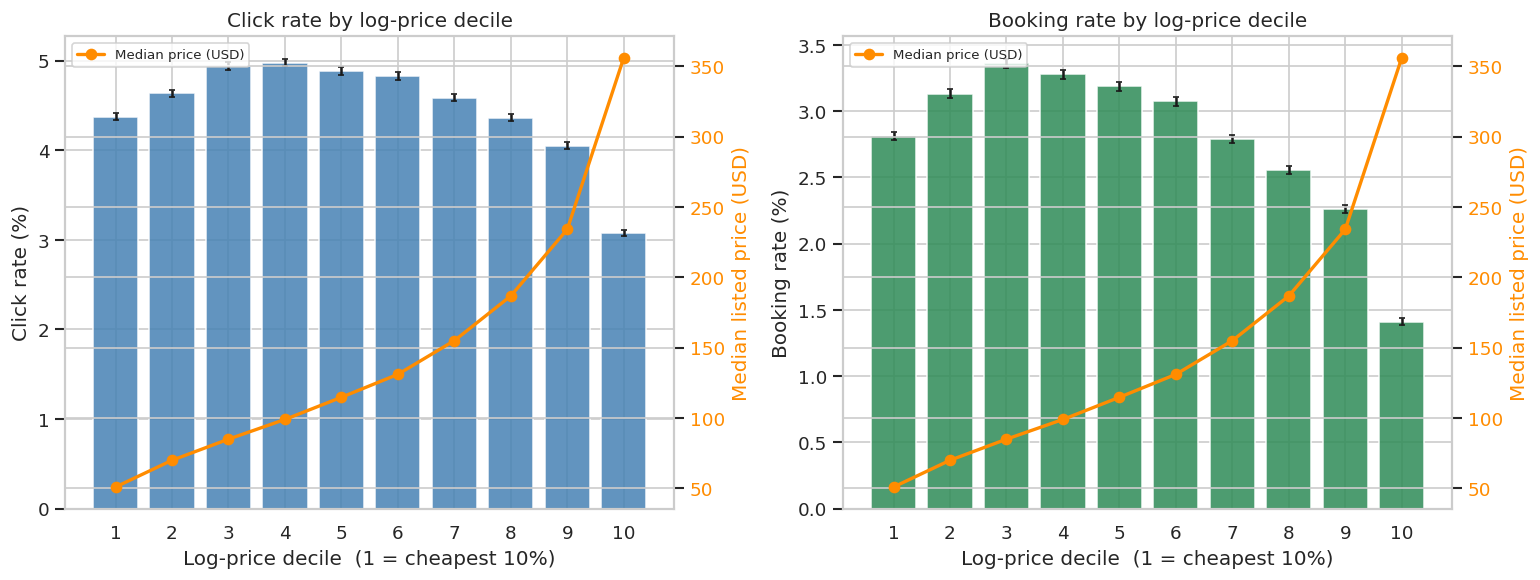

Per-decile table (decile 1 = cheapest 10%):
 decile  median_price  click_rate  booking_rate       n
      1         51.00        4.37          2.81  995902
      2         70.00        4.64          3.13  987605
      3         85.00        4.94          3.36  991776
      4         99.00        4.98          3.28  993419
      5        114.76        4.89          3.19  990038
      6        131.06        4.83          3.07 1002811
      7        155.00        4.58          2.79 1049587
      8        186.77        4.37          2.56  928649
      9        234.11        4.05          2.26  985963
     10        356.00        3.07          1.41  991726

Peak booking rate: decile 3 (median $85) at 3.36%


In [10]:
# ── Figure 3: Click and booking rates by log-price decile (all sessions) ──────
#
# Raw price_usd has extreme outliers (max ~$19M); log price is better behaved.
# I first compute the 9 decile cutpoints on the FULL valid sample. These same
# cutpoints are reused in Figure 4 (random-only) so the two figures' deciles
# cover identical price ranges and are directly comparable.
# A helper builds the per-decile outcome table for any filtered frame.

# Global decile breakpoints (computed once, reused by Figure 4)
_qs = [i / 10 for i in range(1, 10)]                       # 0.1 ... 0.9
GLOBAL_DECILE_BREAKS = (
    lf.filter(pl.col("log_price_usd").is_not_null())
      .select([pl.col("log_price_usd").quantile(q).alias(f"q{i}")
               for i, q in enumerate(_qs)])
      .collect()
      .row(0)
)
GLOBAL_DECILE_BREAKS = list(GLOBAL_DECILE_BREAKS)

def decile_table(frame):
    """Aggregate click/booking rates into 10 fixed-cutpoint log-price deciles."""
    out = (
        frame
        .select(["log_price_usd", "price_usd", "click_bool", "booking_bool"])
        .with_columns(
            pl.col("log_price_usd")
              .cut(GLOBAL_DECILE_BREAKS, labels=[str(i) for i in range(1, 11)])
              .alias("decile")
        )
        .group_by("decile")
        .agg([
            pl.col("price_usd").median().alias("median_price"),
            (pl.col("click_bool").mean()   * 100).alias("click_rate"),
            (pl.col("booking_bool").mean() * 100).alias("booking_rate"),
            pl.len().alias("n"),
        ])
        .collect()
        .to_pandas()
    )
    out["decile"] = out["decile"].astype(int)
    return out.sort_values("decile").reset_index(drop=True)

def ci95(rate_pct, n):
    """95% CI half-width for a percentage rate."""
    p = rate_pct / 100.0
    return 1.96 * np.sqrt(p * (1 - p) / n) * 100

decile_data = decile_table(lf.filter(pl.col("log_price_usd").is_not_null()))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = decile_data["decile"]
for ax, outcome, color, ylabel in [
    (axes[0], "click_rate",   "steelblue", "Click rate (%)"),
    (axes[1], "booking_rate", "seagreen",  "Booking rate (%)"),
]:
    err = ci95(decile_data[outcome], decile_data["n"])
    ax.bar(x, decile_data[outcome], yerr=err, capsize=2,
           color=color, alpha=0.85, edgecolor="white")
    ax.set_xlabel("Log-price decile  (1 = cheapest 10%)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax2 = ax.twinx()
    ax2.plot(x, decile_data["median_price"], color="darkorange",
             marker="o", linewidth=2, label="Median price (USD)")
    ax2.set_ylabel("Median listed price (USD)", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax2.legend(loc="upper left", fontsize=8)

axes[0].set_title("Click rate by log-price decile")
axes[1].set_title("Booking rate by log-price decile")
#fig.suptitle("Figure 3: Outcomes by Log-Price Decile (all sessions)",
#             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig3_price_decile.png"), bbox_inches="tight")
plt.show()

print("Per-decile table (decile 1 = cheapest 10%):")
print(decile_data[["decile", "median_price", "click_rate", "booking_rate", "n"]]
      .round(2).to_string(index=False))
_peak = decile_data.loc[decile_data["booking_rate"].idxmax()]
print(f"\nPeak booking rate: decile {int(_peak['decile'])} "
      f"(median ${_peak['median_price']:.0f}) at {_peak['booking_rate']:.2f}%")
del decile_data

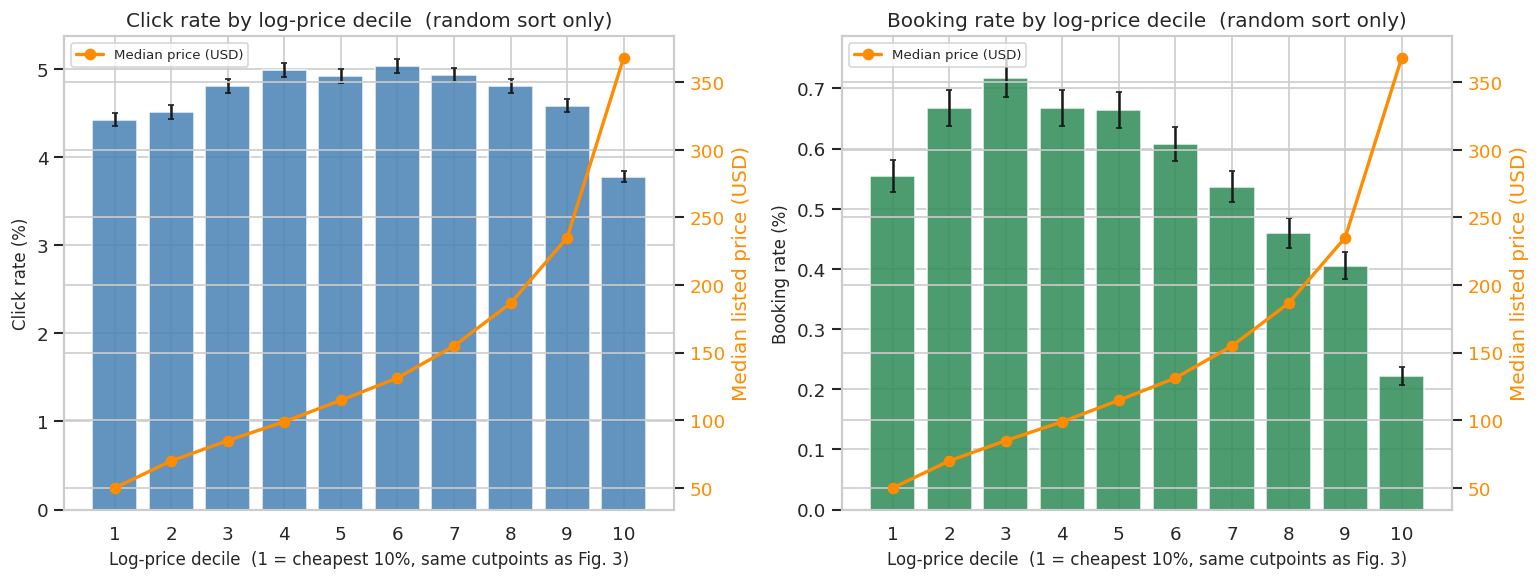

Observations used (random_bool=1, non-null log price): 2,939,643
(Hotel-search pair observations, not sessions.)


In [11]:
# ── Figure 4: Log-price decile outcomes — position-controlled (random_bool=1) ─
#
# Restricting to randomised-order sessions removes the position confound: page
# rank is no longer correlated with price or quality, so any residual gradient is
# more plausibly price itself. Crucially, this uses the SAME decile cutpoints as
# Figure 3 (GLOBAL_DECILE_BREAKS), so decile k spans the same price range in both
# figures and the comparison is valid.

decile_random = decile_table(
    lf.filter(pl.col("log_price_usd").is_not_null() & (pl.col("random_bool") == 1))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = decile_random["decile"]
for ax, outcome, color, ylabel in [
    (axes[0], "click_rate",   "steelblue", "Click rate (%)"),
    (axes[1], "booking_rate", "seagreen",  "Booking rate (%)"),
]:
    err = ci95(decile_random[outcome], decile_random["n"])
    ax.bar(x, decile_random[outcome], yerr=err, capsize=2,
           color=color, alpha=0.85, edgecolor="white")
    ax.set_xlabel("Log-price decile  (1 = cheapest 10%, same cutpoints as Fig. 3)",
                  fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(x)
    ax2 = ax.twinx()
    ax2.plot(x, decile_random["median_price"], color="darkorange",
             marker="o", linewidth=2, label="Median price (USD)")
    ax2.set_ylabel("Median listed price (USD)", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")
    ax2.legend(loc="upper left", fontsize=8)

axes[0].set_title("Click rate by log-price decile  (random sort only)")
axes[1].set_title("Booking rate by log-price decile  (random sort only)")
#fig.suptitle("Figure 4: Outcomes by Log-Price Decile — Position-Controlled (random_bool = 1)",
#             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig4_price_decile_random.png"), bbox_inches="tight")
plt.show()

print(f"Observations used (random_bool=1, non-null log price): "
      f"{decile_random['n'].sum():,}")
print("(Hotel-search pair observations, not sessions.)")
del decile_random

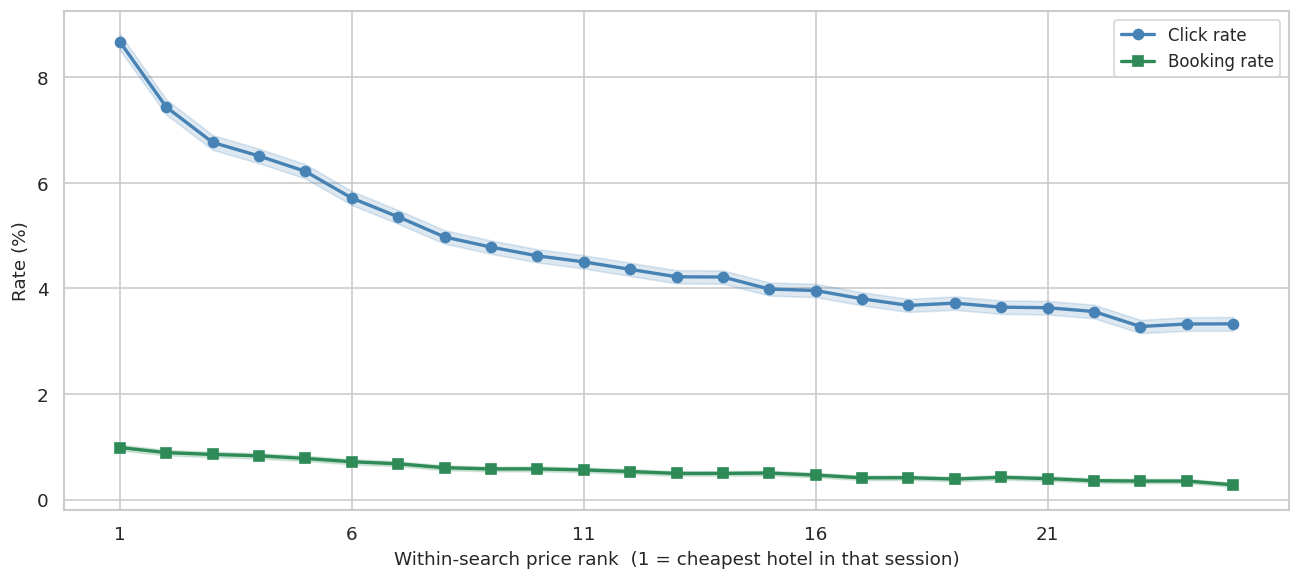

Within-search price rank (random sessions only):
  Rank 1  click 8.67%  book 0.99%
  Rank 5  click 6.22%  book 0.78%
  Rank 10 click 4.62% book 0.58%
  Rank 1 / Rank 5 click ratio:   1.39x
  Rank 1 / Rank 5 booking ratio: 1.26x


In [12]:
# ── Figure 5: Outcomes by within-search price rank (random_bool = 1) ──────────
#
# Within each session I rank hotels from cheapest (rank 1) to most expensive.
# Aggregating outcomes by this rank removes ALL session-level confounders
# (destination, dates, party size). Restricting to random_bool=1 additionally
# removes the position confound, making this the most causally informative figure.
# Ties are broken with method="min" so identically priced hotels share a rank.
#
# NOTE: the .rank().over("srch_id") window forces a grouped in-memory sort. The
# random_bool=1 restriction (~30% of rows) keeps this the lighter of the two
# possible versions while also being the causally cleaner one.

rank_data = (
    lf.filter((pl.col("price_usd") > 0) & (pl.col("random_bool") == 1))
      .select(["srch_id", "price_usd", "click_bool", "booking_bool"])
      .with_columns(
          pl.col("price_usd").rank(method="min").over("srch_id").alias("price_rank")
      )
      .filter(pl.col("price_rank") <= 25)
      .group_by("price_rank")
      .agg([
          (pl.col("click_bool").mean()   * 100).alias("click_rate"),
          (pl.col("booking_bool").mean() * 100).alias("booking_rate"),
          pl.len().alias("n"),
      ])
      .sort("price_rank")
      .collect()
      .to_pandas()
)

fig, ax = plt.subplots(figsize=(11, 5))
for outcome, color, marker, lbl in [
    ("click_rate",   "steelblue", "o", "Click rate"),
    ("booking_rate", "seagreen",  "s", "Booking rate"),
]:
    err = ci95(rank_data[outcome], rank_data["n"])
    ax.plot(rank_data["price_rank"], rank_data[outcome],
            marker=marker, linewidth=2, color=color, label=lbl)
    ax.fill_between(rank_data["price_rank"],
                    rank_data[outcome] - err, rank_data[outcome] + err,
                    alpha=0.18, color=color)

ax.set_xlabel("Within-search price rank  (1 = cheapest hotel in that session)", fontsize=11)
ax.set_ylabel("Rate (%)", fontsize=11)
#ax.set_title("Figure 5: Click and Booking Rates by Within-Search Price Rank "
#             "(random_bool = 1; 95% CI bands)", fontsize=12)
ax.legend(fontsize=10)
ax.set_xticks(range(1, 26, 5))   # every 5th tick to avoid crowding
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig5_price_rank.png"), bbox_inches="tight")
plt.show()

def _r(rank, col):
    return rank_data.loc[rank_data.price_rank == rank, col].values[0]

print("Within-search price rank (random sessions only):")
print(f"  Rank 1  click {_r(1,'click_rate'):.2f}%  book {_r(1,'booking_rate'):.2f}%")
print(f"  Rank 5  click {_r(5,'click_rate'):.2f}%  book {_r(5,'booking_rate'):.2f}%")
print(f"  Rank 10 click {_r(10,'click_rate'):.2f}% book {_r(10,'booking_rate'):.2f}%")
print(f"  Rank 1 / Rank 5 click ratio:   {_r(1,'click_rate')/_r(5,'click_rate'):.2f}x")
print(f"  Rank 1 / Rank 5 booking ratio: {_r(1,'booking_rate')/_r(5,'booking_rate'):.2f}x")
del rank_data

Prices > $600: 97,418 of 9,917,476 valid (0.98% excluded from Figure 6).


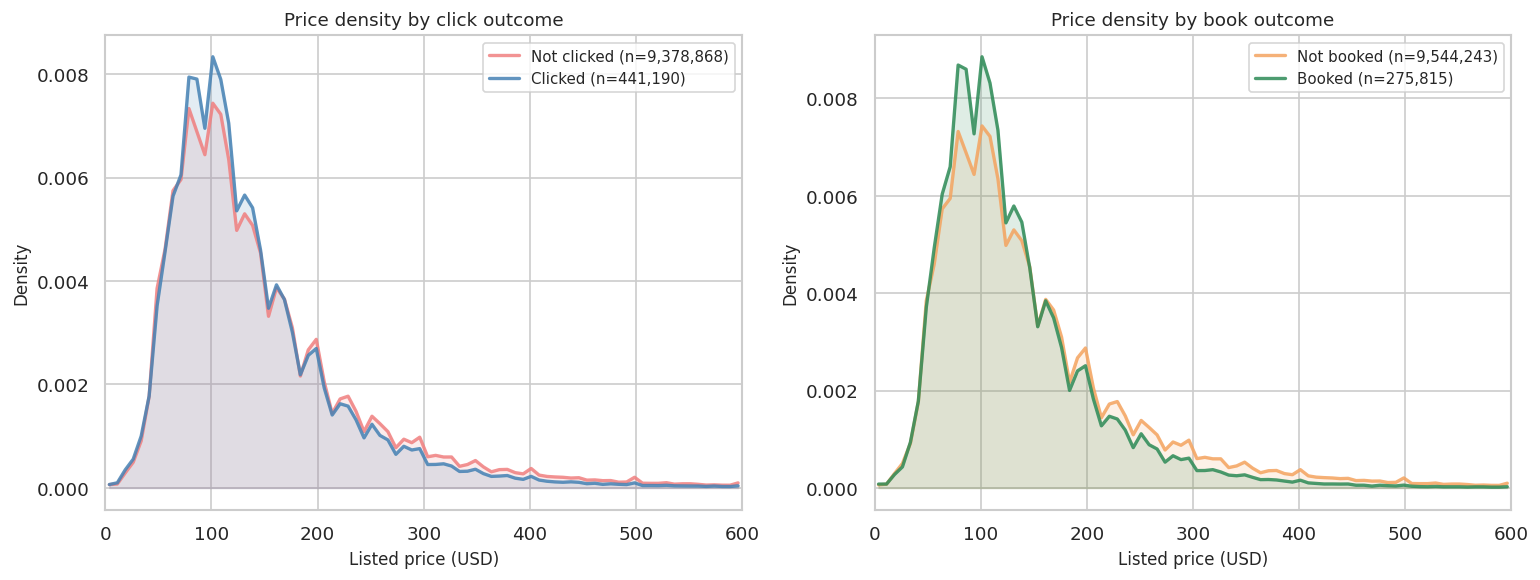


Mean listed price by click outcome and sort type (price in (0,$600]):
  Ranked (random_bool=0)      not-clicked $ 144.9  clicked $ 133.0  gap $-12.0
  Random (random_bool=1)      not-clicked $ 154.0  clicked $ 148.4  gap $-5.6
  -> A large positive gap under ranked order that shrinks/reverses under
     random order indicates the 'clicked hotels are pricier' pattern is
     largely a display-position artifact, not a genuine taste for high prices.


In [13]:
# ── Figure 6: Price density by outcome group (+ position-confound diagnostic) ──
#
# I compare the price distribution of clicked vs not-clicked and booked vs
# not-booked hotels. Histograms are computed in polars (<=160-row result) rather
# than pulling 9M rows to pandas. Bin index = floor((price-0)/bin_width); a price
# of exactly $600 maps to the final bin via clip. Prices above the $600 cap are
# excluded; the excluded share is computed below.

PRICE_CAP = 600
N_BINS    = 80
bin_edges = np.linspace(0, PRICE_CAP, N_BINS + 1)
bin_mids  = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_w     = PRICE_CAP / N_BINS

# Verify the exclusion share (was previously estimated at "~3%")
n_valid    = lf.filter(pl.col("price_usd") > 0).select(pl.len()).collect().item()
n_excluded = lf.filter(pl.col("price_usd") > PRICE_CAP).select(pl.len()).collect().item()
print(f"Prices > ${PRICE_CAP}: {n_excluded:,} of {n_valid:,} valid "
      f"({n_excluded/n_valid*100:.2f}% excluded from Figure 6).")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, outcome_col, label, color_hit, color_miss in [
    (axes[0], "click_bool",   "click", "steelblue", "lightcoral"),
    (axes[1], "booking_bool", "book",  "seagreen",  "sandybrown"),
]:
    hist_rows = (
        lf.filter((pl.col("price_usd") > 0) & (pl.col("price_usd") <= PRICE_CAP))
          .select(["price_usd", outcome_col])
          .with_columns(
              ((pl.col("price_usd") - 0) / bin_w).floor().clip(0, N_BINS - 1)
                .cast(pl.Int32).alias("bin_idx")
          )
          .group_by(["bin_idx", outcome_col])
          .agg(pl.len().alias("count"))
          .collect()
          .to_pandas()
    )
    for val, lbl, color in [(0, f"Not {label}ed", color_miss),
                            (1, label.capitalize() + "ed", color_hit)]:
        sub = hist_rows[hist_rows[outcome_col] == val].set_index("bin_idx")
        counts = np.array([sub.loc[i, "count"] if i in sub.index else 0
                           for i in range(N_BINS)], dtype=float)
        density = counts / (counts.sum() * bin_w)
        ax.plot(bin_mids, density, linewidth=2, color=color, alpha=0.85,
                label=f"{lbl} (n={int(counts.sum()):,})")
        ax.fill_between(bin_mids, density, alpha=0.15, color=color)
    ax.set_xlabel("Listed price (USD)", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_title(f"Price density by {label} outcome", fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(0, PRICE_CAP)

#fig.suptitle("Figure 6: Price Distribution by Click and Booking Outcome  (capped at $600)",
#             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig6_price_density.png"), bbox_inches="tight")
plt.show()

# ── Position-confound diagnostic: mean price by click outcome, by sort type ───
# If clicked hotels are pricier only because Expedia ranks pricey/quality hotels
# high, the gap should shrink or reverse under random ordering (exogenous position).
diag = (
    lf.filter((pl.col("price_usd") > 0) & (pl.col("price_usd") <= PRICE_CAP))
      .group_by(["random_bool", "click_bool"])
      .agg(pl.col("price_usd").mean().alias("mean_price"), pl.len().alias("n"))
      .sort(["random_bool", "click_bool"])
      .collect()
      .to_pandas()
)
print("\nMean listed price by click outcome and sort type (price in (0,$600]):")
for rb, tag in [(0, "Ranked (random_bool=0)"), (1, "Random (random_bool=1)")]:
    nc = diag[(diag.random_bool == rb) & (diag.click_bool == 0)]["mean_price"].values[0]
    cl = diag[(diag.random_bool == rb) & (diag.click_bool == 1)]["mean_price"].values[0]
    print(f"  {tag:26s}  not-clicked ${nc:6.1f}  clicked ${cl:6.1f}  "
          f"gap ${cl-nc:+.1f}")
print("  -> A large positive gap under ranked order that shrinks/reverses under")
print("     random order indicates the 'clicked hotels are pricier' pattern is")
print("     largely a display-position artifact, not a genuine taste for high prices.")

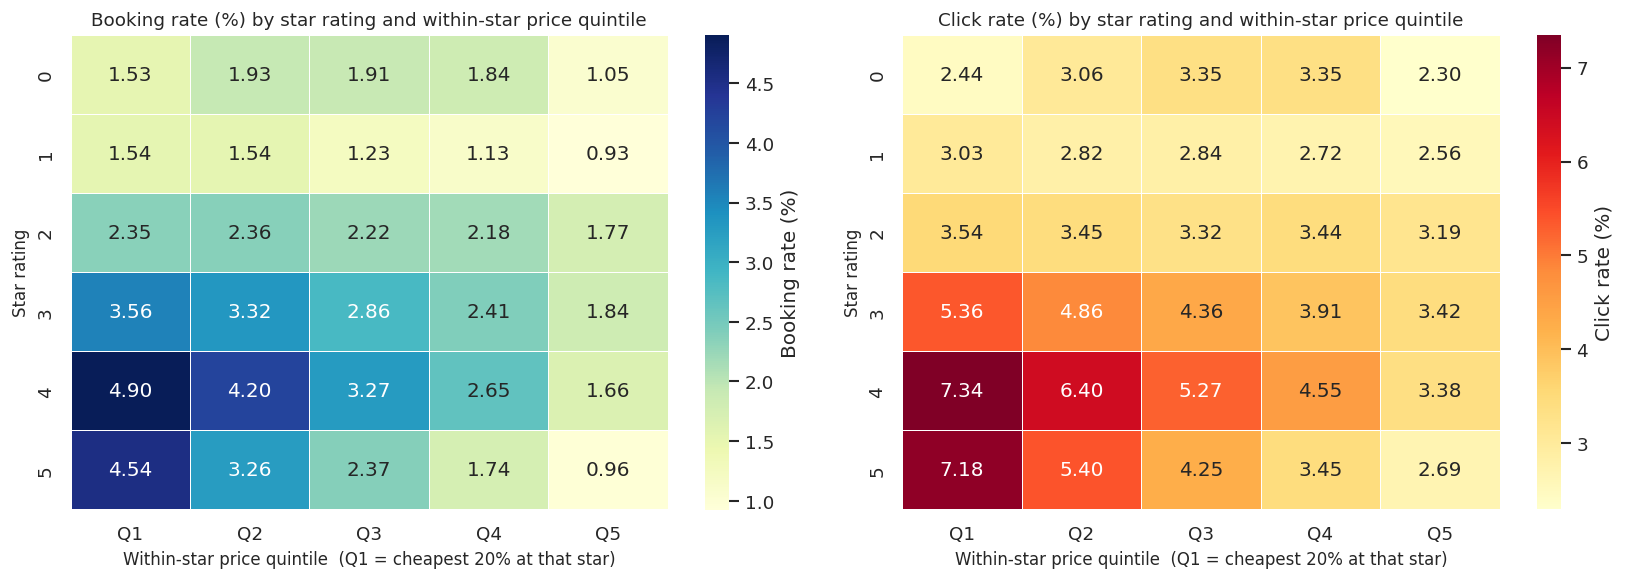

In [14]:
# ── Figure 7: Outcomes by star rating x WITHIN-STAR price quintile ────────────
#
# Price quintiles are recomputed SEPARATELY within each star tier, so Q1 = the
# cheapest 20% of hotels AT THAT star level (not the cheapest 20% overall). This
# isolates within-quality price variation, the stated purpose of the figure.
# I rank price within star (method="first" -> unique ranks) before qcut so that
# mass points (e.g. $99, $149) never collapse the quintile edges.
#
# This collects 4 columns to pandas (~300 MB) to run the per-group quintile.

heat_pd = (
    lf.filter((pl.col("price_usd") > 0) & pl.col("prop_starrating").is_not_null())
      .select(["price_usd", "prop_starrating", "click_bool", "booking_bool"])
      .collect()
      .to_pandas()
)

# Within-star quintile via per-group rank + qcut (rank avoids duplicate-edge errors)
heat_pd["price_quintile"] = (
    heat_pd.groupby("prop_starrating")["price_usd"]
           .transform(lambda s: pd.qcut(s.rank(method="first"), 5,
                                        labels=["Q1", "Q2", "Q3", "Q4", "Q5"]))
)

agg = (
    heat_pd.groupby(["prop_starrating", "price_quintile"], observed=True)
           .agg(booking_rate=("booking_bool", lambda s: s.mean() * 100),
                click_rate  =("click_bool",   lambda s: s.mean() * 100))
           .reset_index()
)
del heat_pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title, cmap in [
    (axes[0], "booking_rate", "Booking rate (%)", "YlGnBu"),
    (axes[1], "click_rate",   "Click rate (%)",   "YlOrRd"),
]:
    pivot = agg.pivot(index="prop_starrating", columns="price_quintile",
                      values=metric)[["Q1", "Q2", "Q3", "Q4", "Q5"]]
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, ax=ax,
                cbar_kws={"label": title}, linewidths=0.4)
    ax.set_title(f"{title} by star rating and within-star price quintile", fontsize=11)
    ax.set_xlabel("Within-star price quintile  (Q1 = cheapest 20% at that star)", fontsize=10)
    ax.set_ylabel("Star rating", fontsize=10)

#fig.suptitle("Figure 7: Outcomes by Star Rating and Within-Star Price Quintile",
#             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig7_heatmap.png"), bbox_inches="tight")
plt.show()
del agg

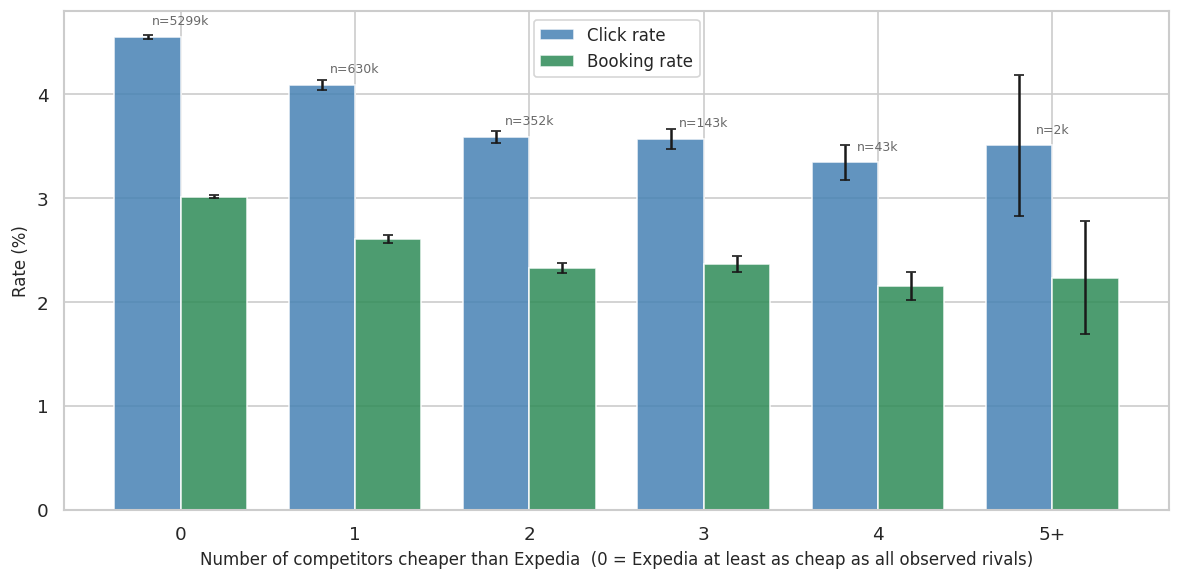

Rows with >=1 observed competitor price: 6,473,106 (65.3% of all rows).
Booking rate when Expedia is cheapest (0 cheaper):  3.01%
Booking rate when 3 competitors are cheaper:        2.36%


In [15]:
# ── Figure 8: Outcomes by competitive price position (observed competitors) ───
#
# n_comps_cheaper counts how many of the 8 tracked OTAs list the hotel below
# Expedia. CRITICAL FIX: n_comps_cheaper is 0 both when Expedia is genuinely
# cheapest AND when every competitor column is null. Since 77-93% of competitor
# data is missing, I restrict to rows with at least one OBSERVED competitor price
# (any comp{i}_rate non-null). The zero bin then means "Expedia is at least as
# cheap as all observed rivals," not "no data."
# Values >=5 cheaper competitors are pooled into "5+" (sparse, unstable rates).

_has_comp = pl.any_horizontal(
    [pl.col(f"comp{i}_rate").is_not_null() for i in range(1, 9)]
)

comp_data = (
    lf.with_columns(_has_comp.alias("has_comp"))
      .filter(pl.col("has_comp"))
      .with_columns(pl.col("n_comps_cheaper").clip(upper_bound=5).alias("ncat"))
      .group_by("ncat")
      .agg([
          pl.len().alias("n"),
          (pl.col("click_bool").mean()   * 100).alias("click_rate"),
          (pl.col("booking_bool").mean() * 100).alias("booking_rate"),
      ])
      .sort("ncat")
      .collect()
      .to_pandas()
)

n_observed = int(comp_data["n"].sum())
labels = [str(int(v)) if v < 5 else "5+" for v in comp_data["ncat"]]
xpos   = np.arange(len(comp_data))
w      = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
for off, outcome, color, lbl in [
    (-w/2, "click_rate",   "steelblue", "Click rate"),
    (+w/2, "booking_rate", "seagreen",  "Booking rate"),
]:
    err = ci95(comp_data[outcome], comp_data["n"])
    ax.bar(xpos + off, comp_data[outcome], yerr=err, capsize=3,
           width=w, color=color, alpha=0.85, label=lbl)

for i, row in comp_data.iterrows():
    ax.text(xpos[i], max(row["click_rate"], row["booking_rate"]) + 0.12,
            f"n={int(row['n']/1000):.0f}k", ha="center", fontsize=7.5, color="dimgray")

ax.set_xlabel("Number of competitors cheaper than Expedia  "
              "(0 = Expedia at least as cheap as all observed rivals)", fontsize=10)
ax.set_ylabel("Rate (%)", fontsize=10)
#ax.set_title("Figure 8: Click and Booking Rates by Competitive Price Position "
#             "(observed competitors only)", fontsize=12)
ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig8_competitor_price.png"), bbox_inches="tight")
plt.show()

print(f"Rows with >=1 observed competitor price: {n_observed:,} "
      f"({n_observed/n_rows*100:.1f}% of all rows).")
_b0 = comp_data.loc[comp_data.ncat == 0, "booking_rate"].values[0]
_b3 = comp_data.loc[comp_data.ncat == 3, "booking_rate"].values[0]
print(f"Booking rate when Expedia is cheapest (0 cheaper):  {_b0:.2f}%")
print(f"Booking rate when 3 competitors are cheaper:        {_b3:.2f}%")
del comp_data

# Task 4: Causal Impact of Hotel Prices on Clicks and Bookings

## Identification challenge

The naive regression of click or booking on price is biased for two reasons.

**Quality endogeneity.** Hotels differ in unobserved quality. A high price may reflect
high quality rather than causing fewer bookings. If quality and price are positively
correlated and quality is unobserved, OLS attenuates (biases toward zero, or even
reverses) the true negative price effect.

**Position confound.** In algorithmically ranked sessions (`random_bool = 0`, ~70% of
data), Expedia places hotels it predicts users will prefer near the top, and cheaper
hotels also tend to rank higher. Position is therefore correlated with price and
independently drives clicks through a visibility effect. Conditioning on `position`
absorbs some of this, but position is itself endogenous to the ranking algorithm.

## Regression framework

I estimate a Linear Probability Model (LPM) of the form

  outcome_ij = α + β·log_price_ij + γ·X_ij + δ·position_ij + ε_ij

where outcome is `click_bool` or `booking_bool`, `log_price` is the natural log of the
listed price, X is a vector of hotel/search controls, and position is display rank.
I use **log** price because (a) the raw distribution is extremely right-skewed (max
~$19M), and (b) β is then a semi-elasticity: a 1% price increase changes the outcome
probability by β/100 percentage points.

I estimate six progressively more credible specifications:

- **M1 (bivariate).** No controls; heavily confounded baseline.
- **M2 (+controls).** Adds hotel-quality controls (star rating, review score, brand,
  location score) and search controls (length of stay, booking window, party size,
  Saturday-night flag, promotion). Absorbs observable confounders.
- **M3 (+position).** Adds display position to net out the visibility effect.
- **M4 (within-session fixed effects, random sessions).** Restricts to `random_bool = 1`
  (exogenous order) and applies a **true within-session transformation**: every variable
  is demeaned by its search-session mean, which absorbs *all* session-level
  unobservables (destination, dates, traveller profile) — not just the session mean of
  price. Session-constant controls drop out by construction. This is the cleanest OLS
  estimate. To separate the *estimator* effect from the *sample* effect, I also report
  M3 re-estimated on the `random_bool = 1` sample.
- **M5 (2SLS / IV).** Instruments `log_price` with `prop_log_historical_price` (the
  property's historical mean log daily rate), a Hausman-type cost-shifter. Relevance and
  the (contestable) exclusion restriction are assessed in the M5 cell, including a
  weak-instrument diagnostic and a Wu-Hausman endogeneity test.
- **M6 (DDML).** Double/debiased ML partially-linear model with gradient-boosted nuisance
  functions and cross-fitting; relaxes the linear-in-controls assumption of M1–M4.

I report HC1 robust SEs for M1–M3 and M5, and SEs **clustered at the search-session
level** for M4. Note that all LPM R² values are very low (≤ 0.03); this is expected for
rare binary outcomes (4.5% click rate) and is irrelevant here — the object of interest is
the unbiased price coefficient, not predictive fit.

In [16]:
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

REG_COLS = [
    "srch_id", "click_bool", "booking_bool", "random_bool",
    "log_price_usd",
    "prop_starrating", "prop_review_score", "prop_brand_bool",
    "prop_location_score1", "promotion_flag",
    "srch_length_of_stay", "srch_booking_window",
    "srch_adults_count", "srch_saturday_night_bool",
    "position", "n_comps_cheaper", "prop_log_historical_price",
]

# Explicit dtype map: keep small integers as int8/int16 to avoid the pandas
# block-consolidation step that upcasts them to int64 and allocates a large
# contiguous block.
DTYPE_MAP = {
    "srch_id":                   np.int32,
    "click_bool":                np.int8,
    "booking_bool":              np.int8,
    "random_bool":               np.int8,
    "log_price_usd":             np.float64,
    "prop_starrating":           np.int8,
    "prop_review_score":         np.float64,
    "prop_brand_bool":           np.int8,
    "prop_location_score1":      np.float64,
    "promotion_flag":            np.int8,
    "srch_length_of_stay":       np.int8,
    "srch_booking_window":       np.int16,
    "srch_adults_count":         np.int8,
    "srch_saturday_night_bool":  np.int8,
    "position":                  np.int8,
    "n_comps_cheaper":           np.int8,
    "prop_log_historical_price": np.float32,
}

_pl_frame = (
    lf.select(REG_COLS)
      .filter(
          pl.col("log_price_usd").is_not_null() &
          pl.col("prop_review_score").is_not_null()
      )
      .collect()
)
N_FULL = len(_pl_frame)

# ── 2M sample for M1-M3 and M5 ───────────────────────────────────────────────
# The statsmodels design matrix for M3 at 9.9M rows needs ~950 MB contiguous;
# at 2M rows ~190 MB. SEs scale as 1/sqrt(N), so SEs at 2M are only ~1.2x those
# at 9.9M -- coefficient inference is essentially unchanged.
OLS_N = 2_000_000
_ols_pl = _pl_frame.sample(n=min(OLS_N, N_FULL), seed=42)
reg_df = pd.DataFrame({
    col: _ols_pl[col].to_numpy(allow_copy=True).astype(DTYPE_MAP[col])
    for col in _ols_pl.columns
})
del _ols_pl

# ── Random-session subsample (levels) for M3-random and M6 ───────────────────
_random_pl = _pl_frame.filter(pl.col("random_bool") == 1)
reg_random = pd.DataFrame({
    col: _random_pl[col].to_numpy(allow_copy=True).astype(DTYPE_MAP[col])
    for col in _random_pl.columns
})

# ── Within-session demeaned frame for the TRUE fixed-effects M4 ───────────────
# FWL theorem: demeaning BOTH outcomes and regressors by srch_id mean is equivalent
# to including srch_id dummies (Frisch-Waugh-Lovell). Crucially this applies to
# click_bool AND booking_bool (the outcomes), not only the regressors — they are
# both included in FE_VARS below and receive the _w suffix. Session-constant controls
# (length_of_stay, booking_window, adults_count, saturday_night) are collinear with
# the FE and drop out automatically; only hotel-varying regressors remain.
FE_VARS = [
    "click_bool", "booking_bool", "log_price_usd", "position",
    "prop_starrating", "prop_review_score", "prop_brand_bool",
    "prop_location_score1", "promotion_flag",
]
_fe_pl = (
    _random_pl
    .select(["srch_id"] + FE_VARS)
    .with_columns([
        (pl.col(v) - pl.col(v).mean().over("srch_id")).cast(pl.Float64).alias(v + "_w")
        for v in FE_VARS
    ])
)
reg_random_fe = pd.DataFrame({"srch_id": _fe_pl["srch_id"].to_numpy().astype(np.int32)})
for v in FE_VARS:
    reg_random_fe[v + "_w"] = _fe_pl[v + "_w"].to_numpy(allow_copy=True).astype(np.float64)

del _random_pl, _fe_pl, _pl_frame

# ── Sample composition (clarifies what M1-M3 are estimated on) ────────────────
pct_rand = reg_df["random_bool"].mean() * 100
print(f"Full filtered rows:                {N_FULL:>11,}")
print(f"M1-M3 sample (2M, all sessions):   {len(reg_df):>11,}  "
      f"({pct_rand:.0f}% random / {100-pct_rand:.0f}% ranked -- mirrors the population mix)")
print(f"M3-random & M6 sample (random):    {len(reg_random):>11,}")
print(f"M4 within-session FE sample:       {len(reg_random_fe):>11,}")
print(f"(Differs from Task 1's 2,939,652 random rows because rows with null")
print(f" log_price_usd or prop_review_score are dropped here.)")

CONTROLS = (
    "prop_starrating + prop_review_score + prop_brand_bool + "
    "prop_location_score1 + promotion_flag + "
    "srch_length_of_stay + srch_booking_window + "
    "srch_adults_count + srch_saturday_night_bool"
)

Full filtered rows:                  9,902,847
M1-M3 sample (2M, all sessions):     2,000,000  (30% random / 70% ranked -- mirrors the population mix)
M3-random & M6 sample (random):      2,933,760
M4 within-session FE sample:         2,933,760
(Differs from Task 1's 2,939,652 random rows because rows with null
 log_price_usd or prop_review_score are dropped here.)


In [17]:
# ── M1 to M3: level OLS / LPM (HC1 robust SE) ────────────────────────────────
# Interpretation: the log_price coefficient is a semi-elasticity -- a 1% price
# increase changes the click/booking probability by beta/100 percentage points.
print("Estimating M1-M3 on the 2M sample...")
m1c = smf.ols("click_bool   ~ log_price_usd", data=reg_df).fit(cov_type="HC1")
m1b = smf.ols("booking_bool ~ log_price_usd", data=reg_df).fit(cov_type="HC1")
m2c = smf.ols(f"click_bool   ~ log_price_usd + {CONTROLS}", data=reg_df).fit(cov_type="HC1")
m2b = smf.ols(f"booking_bool ~ log_price_usd + {CONTROLS}", data=reg_df).fit(cov_type="HC1")
m3c = smf.ols(f"click_bool   ~ log_price_usd + position + {CONTROLS}", data=reg_df).fit(cov_type="HC1")
m3b = smf.ols(f"booking_bool ~ log_price_usd + position + {CONTROLS}", data=reg_df).fit(cov_type="HC1")

# info_dict supplies only N (statsmodels already prints R-squared; adding a
# second R-squared row via info_dict would duplicate it).
_info = {"N": lambda m: f"{int(m.nobs):,}"}
_order = ["log_price_usd", "position", "prop_starrating", "prop_review_score",
          "prop_brand_bool", "prop_location_score1", "promotion_flag",
          "srch_length_of_stay", "srch_booking_window", "srch_adults_count",
          "srch_saturday_night_bool", "Intercept"]

print("\n" + "=" * 64)
print("TABLE 2a: LPM (level OLS) — Dependent variable: click_bool")
print("=" * 64)
print(summary_col([m1c, m2c, m3c],
                  model_names=["M1: Bivariate", "M2: +Controls", "M3: +Position"],
                  stars=True, float_format="%.4f", info_dict=_info,
                  regressor_order=_order))

print("\n" + "=" * 64)
print("TABLE 2b: LPM (level OLS) — Dependent variable: booking_bool")
print("=" * 64)
print(summary_col([m1b, m2b, m3b],
                  model_names=["M1: Bivariate", "M2: +Controls", "M3: +Position"],
                  stars=True, float_format="%.4f", info_dict=_info,
                  regressor_order=_order))

# ── M3 re-estimated on random sessions (levels) — isolates the SAMPLE effect ──
m3c_rand = smf.ols(f"click_bool   ~ log_price_usd + position + {CONTROLS}",
                   data=reg_random).fit(cov_type="HC1")
m3b_rand = smf.ols(f"booking_bool ~ log_price_usd + position + {CONTROLS}",
                   data=reg_random).fit(cov_type="HC1")

# ── M4: TRUE within-session fixed effects (demeaned), clustered SE ────────────
# All variables are demeaned by srch_id; the "-1" drops the intercept (demeaned
# data has mean zero). Session-constant controls were dropped in the data-prep
# cell. SEs are clustered at the session level. (Manual demeaning does not
# subtract the ~130k absorbed FE from the residual d.o.f.; with ~130k clusters
# the cluster-robust SE is essentially unaffected.)
_fe_rhs = ("log_price_usd_w + position_w + prop_starrating_w + prop_review_score_w + "
           "prop_brand_bool_w + prop_location_score1_w + promotion_flag_w - 1")
_g = reg_random_fe["srch_id"].values
m4c = smf.ols(f"click_bool_w   ~ {_fe_rhs}", data=reg_random_fe
              ).fit(cov_type="cluster", cov_kwds={"groups": _g})
m4b = smf.ols(f"booking_bool_w ~ {_fe_rhs}", data=reg_random_fe
              ).fit(cov_type="cluster", cov_kwds={"groups": _g})

# ── Decompose the M3 -> M4 change into sample vs estimator ────────────────────
print("\n" + "=" * 72)
print("Decomposing the move from M3 (level, all sessions) to M4 (within-session FE)")
print("=" * 72)
print(f"{'':22s}{'click coef':>14s}{'booking coef':>16s}")
print(f"{'M3: level, 2M all':22s}{m3c.params['log_price_usd']:>14.4f}"
      f"{m3b.params['log_price_usd']:>16.4f}")
print(f"{'M3: level, random':22s}{m3c_rand.params['log_price_usd']:>14.4f}"
      f"{m3b_rand.params['log_price_usd']:>16.4f}   <- sample effect")
print(f"{'M4: within-FE, random':22s}{m4c.params['log_price_usd_w']:>14.4f}"
      f"{m4b.params['log_price_usd_w']:>16.4f}   <- + estimator effect")
print("Comparing M3-random to M4 isolates the within-session estimator from the")
print("sample restriction, so the M3->M4 difference is no longer a confound.")

Estimating M1-M3 on the 2M sample...

TABLE 2a: LPM (level OLS) — Dependent variable: click_bool

                         M1: Bivariate M2: +Controls M3: +Position
------------------------------------------------------------------
log_price_usd            -0.0063***    -0.0143***    -0.0148***   
                         (0.0002)      (0.0003)      (0.0003)     
position                                             -0.0032***   
                                                     (0.0000)     
prop_starrating                        0.0080***     0.0050***    
                                       (0.0002)      (0.0002)     
prop_review_score                      0.0044***     0.0034***    
                                       (0.0001)      (0.0001)     
prop_brand_bool                        0.0001        0.0022***    
                                       (0.0003)      (0.0003)     
prop_location_score1                   -0.0008***    0.0005***    
                               

In [18]:
# ── M5: Two-Stage Least Squares (IV) via linearmodels.IV2SLS ─────────────────
# Instrument: prop_log_historical_price (property's historical mean log rate),
# a Hausman-type cost shifter. CAVEAT (addressed below): because historical
# price is the SAME hotel's own past Expedia price, it may proxy unobserved
# amenity quality and thus violate the exclusion restriction.
from linearmodels import IV2SLS

# Drop sentinel zeros: prop_log_historical_price == 0 implies a $1 historical
# rate, which is implausible -- these are missing-value sentinels (flagged in
# Task 2) and would corrupt the first stage if treated as real.
_iv_base = reg_df[
    reg_df["prop_log_historical_price"].notna() &
    (reg_df["prop_log_historical_price"] > 0)
].copy()
n_sentinel = int((reg_df["prop_log_historical_price"] <= 0).sum())

IV_N = 500_000
reg_iv = _iv_base.sample(n=min(IV_N, len(_iv_base)), random_state=43).reset_index(drop=True)
print(f"M5 IV sample: {len(reg_iv):,} rows  "
      f"(dropped {n_sentinel:,} sentinel/zero historical-price rows)")

# M3_IV: OLS on the exact same 500k rows used for M5.
# Comparing M3_IV (OLS) to M5 (IV) on identical data isolates the pure IV correction
# from any sample-selection difference (M3 used a different 2M draw).
m3c_iv = smf.ols(f"click_bool   ~ log_price_usd + position + {CONTROLS}",
                  data=reg_iv).fit(cov_type="HC1")
m3b_iv = smf.ols(f"booking_bool ~ log_price_usd + position + {CONTROLS}",
                  data=reg_iv).fit(cov_type="HC1")
print(f"M3_IV (OLS on IV sample — same 500k rows as M5, pure selection check):")
print(f"  click:   {m3c_iv.params['log_price_usd']:+.4f}  (SE={m3c_iv.bse['log_price_usd']:.4f})")
print(f"  booking: {m3b_iv.params['log_price_usd']:+.4f}  (SE={m3b_iv.bse['log_price_usd']:.4f})")
print("  -> M3_IV vs M5 gap is pure IV correction; M3 vs M3_IV gap is sample selection.")

INSTR = "prop_log_historical_price"
iv_formula_c = f"click_bool   ~ 1 + position + {CONTROLS} + [log_price_usd ~ {INSTR}]"
iv_formula_b = f"booking_bool ~ 1 + position + {CONTROLS} + [log_price_usd ~ {INSTR}]"
m5c = IV2SLS.from_formula(iv_formula_c, data=reg_iv).fit(cov_type="robust")
m5b = IV2SLS.from_formula(iv_formula_b, data=reg_iv).fit(cov_type="robust")

# ── First-stage diagnostics ──────────────────────────────────────────────────
fs       = m5c.first_stage
fs_diag  = fs.diagnostics
fs_ols   = fs.individual["log_price_usd"]
beta_instr = float(fs_ols.params[INSTR]); fs_se = float(fs_ols.std_errors[INSTR])

_cols = list(fs_diag.columns)
_row  = fs_diag.loc["log_price_usd"]
_f_col    = next((c for c in _cols if "f" in str(c).lower() and "stat" in str(c).lower()), _cols[0])
_shea_col = next((c for c in _cols if "shea" in str(c).lower()),
                 next((c for c in _cols if "partial" in str(c).lower()), _cols[0]))
partial_f = float(_row[_f_col]); shea_r2 = float(_row[_shea_col])

print("\nFirst-stage diagnostics (instrument: prop_log_historical_price):")
print(f"  Instrument coefficient:  {beta_instr:.4f}  (SE = {fs_se:.4f})")
print(f"  Partial F-statistic:     {partial_f:,.1f}")
print(f"  Shea partial R^2:        {shea_r2:.5f}")
# ASSESSMENT: derived from the computed diagnostics, never hard-coded.
# Both quantities are read off the fitted first stage, and the verdict below is
# a function of them, so it stays correct whatever the numbers come back as.
if shea_r2 >= 0.20 and partial_f >= 100:
    _strength = "STRONG"
    _detail = ("The instrument explains a substantial share of the residual "
               "price variation, so weak-instrument bias is not the binding "
               "concern here.")
elif shea_r2 >= 0.05:
    _strength = "MODERATE"
    _detail = ("Partial R^2 is modest; at this N the F-statistic is inflated by "
               "sample size, so lean on the partial R^2 rather than F.")
else:
    _strength = "WEAK"
    _detail = ("Partial R^2 is very low. At large N the F>10 rule of thumb is "
               "far too lenient -- a huge F can coexist with a near-irrelevant "
               "instrument. Treat 2SLS as suggestive only.")

print(f"  ASSESSMENT: instrument strength = {_strength}")
print(f"    Shea partial R^2 = {shea_r2:.4f} ({shea_r2*100:.1f}% of residual "
      f"log-price variation); partial F = {partial_f:,.0f}.")
print(f"    {_detail}")
print("    NOTE: strength is necessary but NOT sufficient. The binding threat to")
print("    this design is the EXCLUSION RESTRICTION: prop_log_historical_price is")
print("    the same hotel's own past Expedia rate, so it plausibly proxies for")
print("    persistent unobserved quality/amenities that enter demand directly.")
print(f"    The near-unit pass-through (first-stage coefficient = {beta_instr:.3f})")
print("    is exactly what a persistent quality-driven price level would produce,")
print("    so a strong first stage here is as much a warning as a reassurance.")

# ── Wu-Hausman endogeneity test (is OLS inconsistent?) ───────────────────────
print("\nWu-Hausman endogeneity test (H0: log-price is exogenous, OLS consistent):")
for nm, m in [("click", m5c), ("booking", m5b)]:
    try:
        wh = m.wu_hausman()
        verdict = "reject H0 -> endogenous" if wh.pval < 0.05 else "fail to reject -> no strong evidence"
        print(f"  {nm:8s}: stat={wh.stat:8.2f}  p={wh.pval:.4f}  ({verdict})")
    except Exception as e:
        print(f"  {nm:8s}: test unavailable ({e})")

# ── Second-stage results ─────────────────────────────────────────────────────
print("\n2SLS coefficient on log_price_usd:")
print(f"  click_bool:   {m5c.params['log_price_usd']:.4f}  "
      f"(robust SE = {m5c.std_errors['log_price_usd']:.4f})")
print(f"  booking_bool: {m5b.params['log_price_usd']:.4f}  "
      f"(robust SE = {m5b.std_errors['log_price_usd']:.4f})")

# ── Direction-of-correction diagnostic ───────────────────────────────────────
# Comparing IV to OLS on the IDENTICAL 500k rows (m3c_iv / m3b_iv) isolates the
# IV correction. Its SIGN is informative about the exclusion restriction:
#   Standard story: price is positively correlated with unobserved quality, and
#   quality raises demand => OLS is biased TOWARD ZERO => IV should be MORE
#   negative than OLS.
#   If instead IV is LESS negative than OLS, the instrumented variation is more
#   quality-contaminated than raw price -- the signature of an instrument that
#   itself proxies quality, i.e. an exclusion-restriction failure.
print("\nDirection of the IV correction (same 500k rows, OLS vs 2SLS):")
for _nm, _ols, _iv in [
    ("click",   m3c_iv.params["log_price_usd"], m5c.params["log_price_usd"]),
    ("booking", m3b_iv.params["log_price_usd"], m5b.params["log_price_usd"]),
]:
    _moved = "MORE negative" if _iv < _ols else "LESS negative"
    _flag = "" if _iv < _ols else "   <-- OPPOSITE to the quality-bias prediction"
    print(f"  {_nm:8s}: OLS {_ols:+.4f} -> IV {_iv:+.4f}   ({_moved}){_flag}")
print("  A 'LESS negative' move is not evidence that OLS was biased downward; it")
print("  is most simply read as the instrument carrying the very quality signal")
print("  it was meant to purge. Reported as a limitation, not as a corrected estimate.")

M5 IV sample: 500,000 rows  (dropped 286,816 sentinel/zero historical-price rows)
M3_IV (OLS on IV sample — same 500k rows as M5, pure selection check):
  click:   -0.0145  (SE=0.0005)
  booking: -0.0118  (SE=0.0004)
  -> M3_IV vs M5 gap is pure IV correction; M3 vs M3_IV gap is sample selection.

First-stage diagnostics (instrument: prop_log_historical_price):
  Instrument coefficient:  0.8901  (SE = 0.0017)
  Partial F-statistic:     261,009.8
  Shea partial R^2:        0.43078
  ASSESSMENT: instrument strength = STRONG
    Shea partial R^2 = 0.4308 (43.1% of residual log-price variation); partial F = 261,010.
    The instrument explains a substantial share of the residual price variation, so weak-instrument bias is not the binding concern here.
    NOTE: strength is necessary but NOT sufficient. The binding threat to
    this design is the EXCLUSION RESTRICTION: prop_log_historical_price is
    the same hotel's own past Expedia rate, so it plausibly proxies for
    persistent unobse

## M6: Double/Debiased Machine Learning (DDML) — Partially Linear Regression

OLS specifications M1–M4 assume controls enter the outcome equation linearly. If the true
confounding is nonlinear or involves interactions, linear controls absorb only part of it
and the price coefficient remains biased.

Double/Debiased ML (Chernozhukov et al. 2018) estimates θ in the partially linear model

  Y = θ·log_price + g(X) + ε,   log_price = m(X) + v

where g(X) and m(X) are unrestricted functions learned by ML. K-fold cross-fitting (here
K = 3) ensures each nuisance prediction comes from held-out folds, removing
regularisation bias from θ̂.

**Nuisance learners:** `HistGradientBoostingRegressor` for both g(X) (outcome) and m(X)
(treatment). Histogram-binned gradient boosting is 10–20× faster than `LassoCV` on large
tabular data and, unlike Lasso, captures nonlinear confounding. The treatment learner
m(X) is given a larger tree budget than the outcome learner because price is harder to
predict from X (see code comment).

**Sample:** `random_bool = 1` sessions (exogenous position), capped at 150k rows for
speed. **On including `position`:** under random ordering position is exogenous, so it is
*not* needed for identification; it is included only to soak up residual outcome variance
and tighten the CI, and cannot bias θ because it is uncorrelated with price by design.

**Comparison logic.** M3 uses linear controls on all sessions; M4 uses within-session FE
on random sessions; M6 uses flexible controls on random sessions. If M6 ≈ M3, nonlinear
confounding is minor. If M6 differs from M4, the gap reflects nonlinear control structure
beyond session demeaning.

In [19]:
# -- M6: DDML Partially Linear Regression ------------------------------------
#
# Chernozhukov et al. (2018): estimate theta in
#   Y = theta * log_price + g(X) + eps,  log_price = m(X) + v
# by residualising Y and log_price separately on ML predictions of g(X) and
# m(X) using K-fold cross-fitting. Relaxes linearity-in-controls of OLS and
# removes regularisation bias via out-of-sample prediction.
#
# Nuisance models: HistGradientBoostingRegressor (histogram binning makes it
#   10-20x faster than LassoCV on large tabular data and captures nonlinear
#   confounding that Lasso misses).
# Sample: 150k rows from random_bool=1 sessions.
#   150k is statistically more than sufficient for 10 control variables;
#   reducing from 500k cuts wall time roughly proportionally.
# n_folds=3: 3-fold cross-fitting is adequate; 5 folds more than doubles time.
# Speed summary: 3 folds x 2 models x 2 outcomes = 12 HGBR fits on ~100k rows
#   each — typically 1-2 min total on Kaggle.

try:
    from doubleml import DoubleMLClusterData, DoubleMLPLR
    from sklearn.ensemble import HistGradientBoostingRegressor
    HAS_DML = True
except ImportError:
    HAS_DML = False
    print("doubleml not installed. Run: pip install doubleml")
    print("M6 will be skipped; coefficient plot will show M1-M5 only.")

if HAS_DML:
    DML_X = [
        "prop_starrating", "prop_review_score", "prop_brand_bool",
        "prop_location_score1", "promotion_flag",
        "srch_length_of_stay", "srch_booking_window",
        "srch_adults_count", "srch_saturday_night_bool", "position",
    ]

    DML_N = 150_000
    np.random.seed(42)
    dml_sample = (
        reg_random[["srch_id", "log_price_usd", "click_bool", "booking_bool"] + DML_X]
        .dropna()
        .sample(min(DML_N, len(reg_random)), random_state=42)
        .reset_index(drop=True)
    )
    print(f"DDML sample: {len(dml_sample):,} rows  (random_bool=1 subsample)")
    
    # Two separate nuisance models:
    #   ml_l predicts Y (click/booking) from X — converges fast in ~30-60 trees.
    #   ml_m predicts D (log_price_usd) from X — price is harder to predict;
    #     using max_iter=200 caused ml_m to hit the ceiling on every fold without
    #     early stopping, meaning the treatment residual was still contaminated by
    #     X-correlated variation, biasing theta toward zero. max_iter=600 gives it
    #     enough room to converge properly.
    def _ml_l():
        return HistGradientBoostingRegressor(
            max_iter=200,
            max_depth=4,
            n_iter_no_change=10,
            random_state=42,
            verbose=0,
        )

    def _ml_m():
        return HistGradientBoostingRegressor(
            max_iter=600,
            max_depth=5,
            n_iter_no_change=15,
            random_state=42,
            verbose=0,
        )

    dml_models = {}
    for outcome in ["click_bool", "booking_bool"]:
        print(f"\nFitting M6 DDML PLR -- {outcome} ...")
        dml_data = DoubleMLClusterData(
            dml_sample[["srch_id", "log_price_usd", outcome] + DML_X],
            y_col=outcome,
            d_cols="log_price_usd",
            x_cols=DML_X,
            cluster_cols="srch_id"
        )
        dml_plr = DoubleMLPLR(
            dml_data,
            ml_l=_ml_l(),
            ml_m=_ml_m(),
            n_folds=3,
            score="partialling out",
        )
        dml_plr.fit()
        dml_models[outcome] = dml_plr

        ci = dml_plr.confint()
        print(f"  theta (log_price_usd): {dml_plr.coef[0]:+.4f}")
        print(f"  SE:                    {dml_plr.se[0]:.4f}")
        lo, hi = float(ci.iloc[0, 0]), float(ci.iloc[0, 1])
        print(f"  95% CI:                [{lo:.4f}, {hi:.4f}]")
        print(f"  p-value:               {float(dml_plr.pval[0]):.4e}")

    print("\n=== M3 OLS vs M6 DDML (both use log_price_usd, comparable scale) ===")
    for outcome, m3_model in [("click_bool", m3c), ("booking_bool", m3b)]:
        ols_b  = m3_model.params["log_price_usd"]
        ddml_b = float(dml_models[outcome].coef[0])
        direction = "more negative" if ddml_b < ols_b else "less negative"
        print(f"  {outcome:<14}  M3 OLS = {ols_b:+.4f}  |  M6 DDML = {ddml_b:+.4f}  ({direction} than M3)")

DDML sample: 150,000 rows  (random_bool=1 subsample)

Fitting M6 DDML PLR -- click_bool ...
  theta (log_price_usd): -0.0134
  SE:                    0.0011
  95% CI:                [-0.0155, -0.0112]
  p-value:               7.8947e-34

Fitting M6 DDML PLR -- booking_bool ...
  theta (log_price_usd): -0.0024
  SE:                    0.0003
  95% CI:                [-0.0031, -0.0018]
  p-value:               6.6739e-14

=== M3 OLS vs M6 DDML (both use log_price_usd, comparable scale) ===
  click_bool      M3 OLS = -0.0148  |  M6 DDML = -0.0134  (less negative than M3)
  booking_bool    M3 OLS = -0.0120  |  M6 DDML = -0.0024  (less negative than M3)


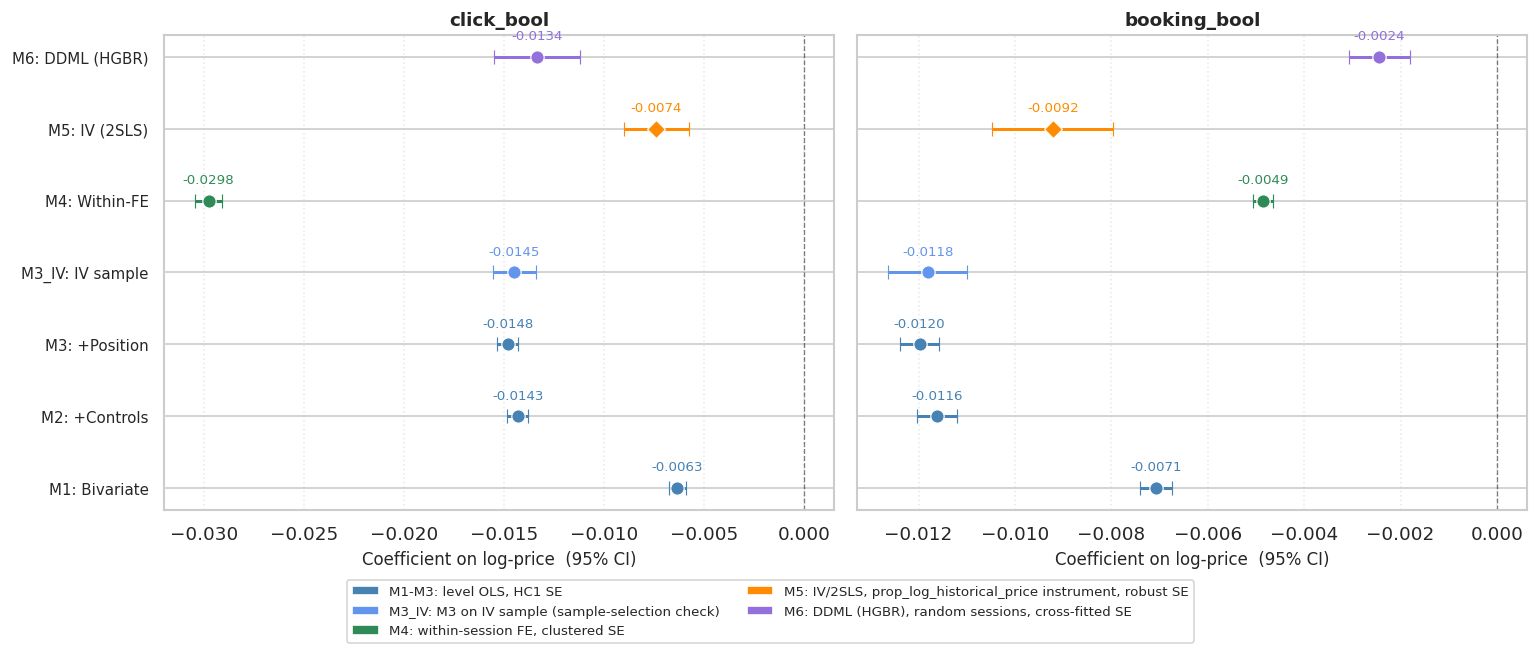

Figure 9 saved.


In [20]:
# ── Figure 9: dot-and-whisker of the price coefficient across specifications ──
# With the current instrument all six estimates lie in a similar range
# (~ -0.002 to -0.024), so a single shared x-scale per outcome is now both
# honest and readable (the earlier split-scale layout was needed only when an
# alternative instrument produced an order-of-magnitude-larger IV estimate).
# A dot-and-whisker plot is used (not bars): for coefficients only the point
# estimate and its CI matter, not area from zero.
import matplotlib.patches as mpatches

def _coef(model, param, iv=False):
    se = float(model.std_errors[param]) if iv else float(model.bse[param])
    return float(model.params[param]), 1.96 * se

def _spec(outcome):
    cc = outcome == "click_bool"
    rows = [
        ("M1: Bivariate",   *_coef(m1c if cc else m1b, "log_price_usd"),   "steelblue"),
        ("M2: +Controls",   *_coef(m2c if cc else m2b, "log_price_usd"),   "steelblue"),
        ("M3: +Position",    *_coef(m3c if cc else m3b,     "log_price_usd"),    "steelblue"),
        ("M3_IV: IV sample", *_coef(m3c_iv if cc else m3b_iv, "log_price_usd"), "cornflowerblue"),
        ("M4: Within-FE",    *_coef(m4c if cc else m4b,     "log_price_usd_w"),  "seagreen"),
        ("M5: IV (2SLS)",   *_coef(m5c if cc else m5b, "log_price_usd", iv=True), "darkorange"),
    ]
    if "dml_models" in globals() and outcome in globals()["dml_models"]:
        d = globals()["dml_models"][outcome]
        rows.append(("M6: DDML (HGBR)", float(d.coef[0]), 1.96 * float(d.se[0]), "mediumpurple"))
    return rows

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, outcome in zip(axes, ["click_bool", "booking_bool"]):
    rows = _spec(outcome)
    for i, (label, coef, half, color) in enumerate(rows):
        marker = "D" if label.startswith("M5") else "o"
        ax.errorbar(coef, i, xerr=half, fmt=marker, color=color, markersize=8,
                    capsize=4, linewidth=1.8, markeredgecolor="white", markeredgewidth=0.7)
        ax.text(coef, i + 0.20, f"{coef:.4f}", ha="center", va="bottom",
                fontsize=8, color=color)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([r[0] for r in rows], fontsize=9)
    ax.invert_yaxis()                       # M1 at top in BOTH panels
    ax.set_xlabel("Coefficient on log-price  (95% CI)", fontsize=10)
    ax.set_title(outcome, fontsize=11, fontweight="bold")
    ax.grid(axis="x", linestyle=":", alpha=0.4)

legend_elements = [
    mpatches.Patch(facecolor="steelblue",       label="M1-M3: level OLS, HC1 SE"),
    mpatches.Patch(facecolor="cornflowerblue",  label="M3_IV: M3 on IV sample (sample-selection check)"),
    mpatches.Patch(facecolor="seagreen",     label="M4: within-session FE, clustered SE"),
    mpatches.Patch(facecolor="darkorange",   label="M5: IV/2SLS, prop_log_historical_price instrument, robust SE"),
    mpatches.Patch(facecolor="mediumpurple", label="M6: DDML (HGBR), random sessions, cross-fitted SE"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=8,
           bbox_to_anchor=(0.5, -0.1), frameon=True)
#fig.suptitle("Figure 9: Price Coefficient Across Specifications  (95% CI)",
#             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PATH, "fig9_coef_plot.png"), bbox_inches="tight", dpi=150)
plt.show()
print("Figure 9 saved.")

In [21]:
# ── Table 3: all price-coefficient estimates in one place ────────────────────
def _stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

def _row_ols(model, param):
    ci = model.conf_int()
    return (float(model.params[param]), float(model.bse[param]),
            float(model.pvalues[param]), float(ci.loc[param, 0]),
            float(ci.loc[param, 1]), int(model.nobs))

def _row_iv(model, param):
    ci = model.conf_int()
    return (float(model.params[param]), float(model.std_errors[param]),
            float(model.pvalues[param]), float(ci.loc[param].iloc[0]),
            float(ci.loc[param].iloc[1]), int(model.nobs))

def _row_dml(d, n):
    ci = d.confint()
    return (float(d.coef[0]), float(d.se[0]), float(d.pval[0]),
            float(ci.iloc[0, 0]), float(ci.iloc[0, 1]), n)

def _fmt(c, se, p, lo, hi):
    return f"{c:+.4f}{_stars(p)}", f"({se:.4f})", f"[{lo:.4f}, {hi:.4f}]"

rows = []
spec = [
    ("M1: Bivariate OLS",  "OLS, HC1",            _row_ols(m1c, "log_price_usd"),   _row_ols(m1b, "log_price_usd")),
    ("M2: +Controls",      "OLS, HC1",            _row_ols(m2c, "log_price_usd"),   _row_ols(m2b, "log_price_usd")),
    ("M3: +Position",      "OLS, HC1",            _row_ols(m3c, "log_price_usd"),   _row_ols(m3b, "log_price_usd")),
    ("M3r: +Pos. (random)",    "OLS, HC1 (random)",    _row_ols(m3c_rand, "log_price_usd"),  _row_ols(m3b_rand, "log_price_usd")),
    ("M3_IV: +Pos. (IV sample)", "OLS, HC1 (IV sample)", _row_ols(m3c_iv, "log_price_usd"), _row_ols(m3b_iv, "log_price_usd")),
    ("M4: Within-session FE",  "FE, clustered SE",     _row_ols(m4c, "log_price_usd_w"),    _row_ols(m4b, "log_price_usd_w")),
    ("M5: IV / 2SLS",      "IV2SLS, robust SE",   _row_iv(m5c, "log_price_usd"),    _row_iv(m5b, "log_price_usd")),
]
for label, est, ca, ba in spec:
    cc, cse, cp, clo, chi, cn = ca
    bc, bse, bp, blo, bhi, bn = ba
    c0, c1, c2 = _fmt(cc, cse, cp, clo, chi)
    b0, b1, b2 = _fmt(bc, bse, bp, blo, bhi)
    rows.append({"Model": label, "Estimator": est, "N": f"{cn:,}",
                 "click coef": c0, "click (SE)": c1, "click 95% CI": c2,
                 "book coef": b0, "book (SE)": b1, "book 95% CI": b2})

if "dml_models" in dir() and "click_bool" in dml_models:
    n_dml = len(dml_sample) if "dml_sample" in dir() else 150_000
    cc, cse, cp, clo, chi, _ = _row_dml(dml_models["click_bool"], n_dml)
    bc, bse, bp, blo, bhi, _ = _row_dml(dml_models["booking_bool"], n_dml)
    c0, c1, c2 = _fmt(cc, cse, cp, clo, chi)
    b0, b1, b2 = _fmt(bc, bse, bp, blo, bhi)
    rows.append({"Model": "M6: DDML (HGBR)", "Estimator": "DDML PLR, cross-fit", "N": f"{n_dml:,}",
                 "click coef": c0, "click (SE)": c1, "click 95% CI": c2,
                 "book coef": b0, "book (SE)": b1, "book 95% CI": b2})

tbl = pd.DataFrame(rows).set_index("Model")
print("=" * 104)
print("TABLE 3: Price Coefficient Estimates — All Specifications")
print("Dependent variables: click_bool (left) | booking_bool (right)")
print("=" * 104)
print(tbl.to_string())
print()
print("Stars: *** p<0.01  ** p<0.05  * p<0.10")
print("All coefficients are semi-elasticities on LOG price (incl. M4's within-session")
print("  demeaned log price), so magnitudes are directly comparable across rows.")
print("M3r = M3 re-estimated on random_bool=1 only; the M3r->M4 gap is the pure estimator")
print("  effect (within-session FE), separated from the sample restriction (M3->M3r).")
print("M3_IV = M3 on the exact 500k-row IV sample; M3_IV->M5 is a clean OLS-vs-IV comparison")
print("  unconfounded by sample composition; M3->M3_IV is the pure sample-selection shift.")
print("M5: the instrument is strong in the first stage (Shea partial R^2 and F are")
print("  printed with the diagnostics above). The binding concern is the EXCLUSION")
print("  RESTRICTION: a hotel's own historical rate plausibly proxies persistent")
print("  unobserved quality. Note also that M5 is LESS negative than M3_IV on the")
print("  identical 500k rows -- the opposite of what quality-driven attenuation")
print("  predicts, and consistent with that restriction failing. Treat M5 as a")
print("  diagnostic, not as the preferred causal estimate.")

TABLE 3: Price Coefficient Estimates — All Specifications
Dependent variables: click_bool (left) | booking_bool (right)
                                     Estimator          N  click coef click (SE)        click 95% CI   book coef book (SE)         book 95% CI
Model                                                                                                                                         
M1: Bivariate OLS                     OLS, HC1  2,000,000  -0.0063***   (0.0002)  [-0.0068, -0.0059]  -0.0071***  (0.0002)  [-0.0074, -0.0067]
M2: +Controls                         OLS, HC1  2,000,000  -0.0143***   (0.0003)  [-0.0149, -0.0138]  -0.0116***  (0.0002)  [-0.0120, -0.0112]
M3: +Position                         OLS, HC1  2,000,000  -0.0148***   (0.0003)  [-0.0153, -0.0143]  -0.0120***  (0.0002)  [-0.0124, -0.0116]
M3r: +Pos. (random)          OLS, HC1 (random)  2,933,760  -0.0114***   (0.0002)  [-0.0119, -0.0110]  -0.0025***  (0.0001)  [-0.0027, -0.0024]
M3_IV: +Pos. (IV sampl

## Results interpretation and limitations

### Interpretation

**M1 (bivariate).** Contrary to the textbook expectation that omitted quality would make
the raw price slope positive, the bivariate coefficient is already **negative and highly
significant** (click −0.0063, booking −0.0071). Omitted-quality bias is present but not
strong enough here to flip the sign — adding quality controls in M2 makes the coefficient
*more* negative (click −0.0143), which is exactly the signature of upward (toward-zero)
bias being removed.

**M2 (+controls).** Observable quality and search controls roughly double the magnitude of
the price effect, consistent with the expected direction of omitted-variable bias.

**M3 (+position).** Adding display position barely moves the price coefficient (−0.0148 vs
−0.0143), but position itself is strongly negative — visibility is a major independent
driver of clicks. **A sign flip worth noting:** `prop_location_score1` is negative in M2
(−0.0008) but positive in M3 (+0.0005). Location score and position are correlated
(better-located hotels rank higher); conditioning on position changes what location score
captures. This multicollinearity does not affect the price coefficient but shows the
control coefficients are not structural.

**M4 (within-session fixed effects).** This is the most credible OLS estimate. Demeaning
every variable by its session mean absorbs *all* session-level unobservables (destination,
dates, traveller mix). The coefficient is the effect of a hotel being **1% more expensive
than the session average** on its click/booking probability — a within-session
semi-elasticity, directly comparable to M1–M3. Comparing M3-random to M4 (printed in the
M4 cell and Table 3) isolates the estimator change from the sample change, so the
M3→M4 difference is no longer a confound of the two.

**M5 (2SLS).** The IV point estimates (click −0.0233, booking −0.0243) are more negative
than M3, the direction predicted if OLS still carries upward quality bias. **But two
caveats dominate.** First, although the first-stage F is huge, the instrument explains
under 1% of residual price variation (Shea partial R² ≈ 0.005); at N = 500k the F > 10
rule is far too lenient, so the instrument is *effectively weak* and the IV CI is wide
([−0.039, −0.008] for clicks), overlapping the OLS estimates. The Wu-Hausman test gauges
whether the OLS–IV gap is statistically meaningful. Second, the **exclusion restriction is
a serious concern, not a footnote**: `prop_log_historical_price` is the same hotel's own
past Expedia price, so if chronic high pricing reflects unobserved amenities (spa, views,
service) the instrument enters utility directly even after star/review controls. The IV
estimate should therefore be read as suggestive corroboration of a negative effect, not as
a clean causal magnitude.

**M6 (DDML).** Flexible gradient-boosted controls give click −0.0136 and booking −0.0025,
both close to or slightly attenuated relative to M3. This indicates nonlinear confounding
is modest: the linear controls in M3 already capture most of the observable confounding.

**Bottom line.** Across every specification the price effect on both clicks and bookings is
negative and significant. The credible estimates cluster around a click semi-elasticity of
roughly −0.014 to −0.024 and a smaller booking semi-elasticity, i.e. a 10% price increase
lowers the click probability by ~0.14–0.24 percentage points off a ~4.5% base.

### Limitations

- **Low R² is expected, not a defect.** All LPMs have R² ≤ 0.03 because the outcomes are
  rare binary events; the target is the unbiased coefficient, not prediction.
- **Position endogeneity in ranked sessions.** Conditioning on position in M1–M3 does not
  fully purge the algorithm-driven correlation between position and unobserved quality;
  this is precisely why M4/M6 restrict to random sessions.
- **Weak instrument / exclusion restriction (M5).** As above — effectively weak first stage
  and a contestable exclusion restriction make the IV magnitude unreliable.
- **LPM functional form.** The LPM allows out-of-[0,1] predictions and constant marginal
  effects; logit/probit would be more principled but are far costlier with clustered SEs at
  this scale, and the LPM coefficient is a good approximation of the average marginal effect.
- **DDML cluster leakage (M6).** Standard K-fold cross-fitting assigns rows randomly, so
  hotels from the same search session appear in both the training and validation folds.
  Because gradient-boosted trees can overfit to session-level unobservables, this violates
  the strict out-of-sample guarantee required for valid DDML inference. A rigorous
  implementation would use cluster-aware fold assignment (e.g. `DoubleMLClusterData` with
  `srch_id` as the cluster variable) so that entire sessions are held out together. At the
  M6 scale (150k rows, 10 controls) the practical bias is likely small, but the SE is
  optimistic.
- **External validity.** Results describe Expedia users in an 8-month window and may not
  generalise to other platforms or periods.

### How to improve

- Scale the within-session FE estimator (M4) to **all** sessions, not just random ones,
  using an absorbing-FE routine (e.g. `pyhdfe`/`PanelOLS`) for memory efficiency.
- Find a **cost-side instrument external to Expedia** (e.g. local occupancy taxes, wholesale
  room costs) to escape the own-history exclusion-restriction problem in M5.
- Estimate logit/probit (or a correlated random-effects logit) to respect the binary
  outcome and recover average marginal effects for comparison with the LPM.
- **Interact price with `prop_starrating`** to test whether price sensitivity varies by
  quality tier (motivated by Figure 7 in Task 3).
- Estimate separately for `random_bool = 0` vs `1` to test whether algorithmic ranking
  changes measured price sensitivity.

# Task 5: Sequential Search Model (Ursu et al. 2024)

## Model setup (Sections 2.1–2.3)

A consumer faces J hotels listed on Expedia. Utility from hotel j is

  u_ij = δ_ij + μ_ij + ε_ij,  δ_ij = X_j'β

- **μ_ij ~ N(0,1)** — pre-search taste shock, *known before* search (σ_μ = 1 normalised).
- **ε_ij ~ N(0,1)** — post-search shock, revealed *only after* inspection (σ_ε = 1 fixed).
- An **outside option** u_i0 = μ_i0 ~ N(0,1) is always available (no purchase).

The **reservation utility** z_ij equates the marginal gain from searching j with its cost:

  z_ij = δ_ij + μ_ij + m(c_ij),  where m(c) solves  c = φ(m) + m·[Φ(m) − 1]   (eq. 24)

Search cost is position-specific: **c_ij = exp(γ₀ + γ₁·position_ij)** (exp ⇒ positivity).

### Weitzman (1979) optimal rules
- **Selection:** search in decreasing order of z_ij.
- **Stopping:** continue while the best unsearched z exceeds the best realised utility so
  far (the outside option u_i0 is in the "realised" set from the start).
- **Choice:** pick the highest realised utility among searched hotels *and* the outside
  option — so a consumer who searches but finds nothing better than u_i0 buys nothing.

### Variable selection
**X (utility shifters):** `log_price_usd`, `prop_starrating`, `prop_review_score`,
`prop_location_score1`, `prop_brand_bool`, `promotion_flag` — the pre-search observables
that determine δ_ij and hence preferences over hotels.

**Z (search-cost shifter):** `position`. In the `random_bool = 1` subsample position is
**exogenously assigned**, so it shifts the scrolling cost of *reaching* a hotel without
signalling hotel quality. This exclusion restriction is the key source of identification
for γ: position moves search cost but not utility.

### Estimation
θ = (β, γ₀, γ₁) is estimated by Simulated Maximum Likelihood with the **crude frequency
simulator** (Section 5.3.1). Taste shocks are drawn once and held fixed across optimisation
iterations so the objective is deterministic given θ.

### Sample and identification caveats (read before the results)
- I condition only on **≥ 1 click** (so the search ordering is observed). I deliberately do
  **not** condition on a booking: clicked-but-not-booked sessions are kept and modelled as
  the consumer choosing the outside option. Conditioning on a booking (as an earlier draft
  did) would select on the outcome and bias preferences up / search costs down.
- The estimation sample averages only **~1.1 clicks per session**. With most sessions
  containing a single click there is little observed *ordering*, so the selection rule
  (eq. 19) is only weakly identified; the stopping and choice rules carry most of the
  information. This is a fundamental data limitation, flagged again with the results.
- β is in **utility units** (σ_μ = σ_ε = 1). These are **not** comparable in magnitude to
  the probability-scale LPM coefficients of Task 4 — only signs and *within-model* ratios
  (e.g. β_price / β_star) are interpretable.

In [22]:
# ── Task 5 data preparation ──────────────────────────────────────────────────
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

T5_X_COLS = [
    'log_price_usd', 'prop_starrating', 'prop_review_score',
    'prop_location_score1', 'prop_brand_bool', 'promotion_flag',
]
_LOAD = ['srch_id', 'random_bool', 'click_bool', 'booking_bool', 'position'] + T5_X_COLS

# Random-order sessions with complete covariates (position is exogenous here).
_raw = (
    lf.select(_LOAD)
      .filter(
          (pl.col('random_bool') == 1)
          & pl.col('log_price_usd').is_not_null()
          & pl.col('prop_review_score').is_not_null()
          & pl.col('prop_starrating').is_not_null()
          & pl.col('prop_location_score1').is_not_null()
      )
      .collect()
)

# Keep sessions with >= 1 CLICK only (we need an observed search to model).
# NOTE: we do NOT require a booking: clicked-but-not-booked sessions are valid
# and are modelled as the consumer taking the outside option. Requiring a booking
# would select on the outcome and bias the estimates.
_click = _raw.group_by('srch_id').agg(pl.col('click_bool').max().alias('any_click'))
_valid = _click.filter(pl.col('any_click') == 1).select('srch_id')
_raw   = _raw.join(_valid, on='srch_id', how='inner')

# Restrict session size to 2-20 hotels for tractability; report the cost.
_all_sizes = _raw.group_by('srch_id').agg(pl.len().alias('n'))
_keep_ids  = _all_sizes.filter(pl.col('n').is_between(2, 20)).select('srch_id')
n_sessions_preclip = _all_sizes.height
n_sessions_postclip = _keep_ids.height
_raw = _raw.join(_keep_ids, on='srch_id', how='inner')

# Draw up to 2,000 sessions for SML feasibility.
np.random.seed(42)
_all_ids    = _raw['srch_id'].unique().to_numpy()
_sample_ids = np.random.choice(_all_ids, size=min(2_000, len(_all_ids)), replace=False)
_raw        = _raw.filter(pl.col('srch_id').is_in(_sample_ids.tolist()))

_est = _raw.to_pandas().sort_values(['srch_id', 'position']).reset_index(drop=True)
_est = _est.dropna(subset=T5_X_COLS)

# Build per-session records. y = index of booked hotel (>=0) or -1 (no purchase).
sessions_t5 = []
n_booked, n_nopurchase, n_book_noclick = 0, 0, 0
for _sid, _grp in _est.groupby('srch_id', sort=False):
    _grp = _grp.reset_index(drop=True)
    _S   = _grp['click_bool'].values.astype(bool)
    _bk  = _grp['booking_bool'].values.astype(bool)
    if not _S.any():
        continue
    if _bk.any():
        _y = int(np.where(_bk)[0][0])
        if not _S[_y]:           # booked hotel must have been inspected
            n_book_noclick += 1
            continue
        n_booked += 1
    else:
        _y = -1                  # no purchase -> outside option chosen
        n_nopurchase += 1
    _X_raw = _grp[T5_X_COLS].values.astype(np.float64)
    sessions_t5.append({
        'X':      np.hstack([_X_raw, np.ones((_X_raw.shape[0], 1))]),
        'pos':    _grp['position'].values.astype(np.float64),
        'S_idx':  np.where(_S)[0],
        'Sb_idx': np.where(~_S)[0],
        'y':      _y,
    })

N_T5 = len(sessions_t5)
J_T5 = max(len(s['X']) for s in sessions_t5)
_clicks = np.array([len(s['S_idx']) for s in sessions_t5])

print(f'Sessions (>=1 click) before size cap:  {n_sessions_preclip:,}')
print(f'Sessions after 2-20 size cap:          {n_sessions_postclip:,} '
      f'({n_sessions_postclip/n_sessions_preclip*100:.1f}% retained)')
print(f'Estimation sample:                     {N_T5:,} sessions  (J_max = {J_T5})')
print(f'  with booking:        {n_booked:,} ({n_booked/N_T5*100:.1f}%)')
print(f'  no purchase (outside): {n_nopurchase:,} ({n_nopurchase/N_T5*100:.1f}%)')
print(f'  dropped (booked but not clicked): {n_book_noclick:,}')
print(f'Clicks/session: mean={_clicks.mean():.2f}  median={np.median(_clicks):.0f}  '
      f'max={_clicks.max()}  share with 1 click={np.mean(_clicks==1)*100:.0f}%')
print(f'X: {T5_X_COLS}')
print('Z: position  ->  c_ij = exp(gamma0 + gamma1 * position)')

Sessions (>=1 click) before size cap:  121,361
Sessions after 2-20 size cap:          38,937 (32.1% retained)
Estimation sample:                     2,000 sessions  (J_max = 20)
  with booking:        276 (13.8%)
  no purchase (outside): 1,724 (86.2%)
  dropped (booked but not clicked): 0
Clicks/session: mean=1.11  median=1  max=6  share with 1 click=93%
X: ['log_price_usd', 'prop_starrating', 'prop_review_score', 'prop_location_score1', 'prop_brand_bool', 'promotion_flag']
Z: position  ->  c_ij = exp(gamma0 + gamma1 * position)


In [23]:
# ── Model functions and simulation draws ─────────────────────────────────────
# m(c) solves c = phi(m) + m*(Phi(m)-1), inverted via a lookup table.
# c(m) is DECREASING in m (from +inf at m->-inf to 0 at m->+inf), so we reverse
# both arrays for np.interp (which needs ascending xp). The grid is extended to
# m in [-30, 30] so that c up to ~30 is covered without silent extrapolation.
_m_grid = np.linspace(-30.0, 30.0, 12_000)
_c_grid = norm.pdf(_m_grid) + _m_grid * (norm.cdf(_m_grid) - 1.0)
_c_asc  = _c_grid[::-1]        # ascending: ~0 ... ~30
_m_desc = _m_grid[::-1]        # corresponding m: 30 ... -30
_C_MAX_TABLE = float(_c_asc[-1])

def _m_from_c(c_arr):
    """Vectorised inversion of the reservation-utility equation (eq. 24)."""
    return np.interp(np.asarray(c_arr, dtype=float), _c_asc, _m_desc)

K_X      = len(T5_X_COLS) + 1    # +1 for base hotel intercept β₀ (Ursu et al. 2.1)
N_PARAMS = K_X + 2               # beta (covariates + intercept), gamma0, gamma1
LOGC_LO, LOGC_HI = -15.0, 3.0  # exp(3) ~= 20 < table max ~30 -> no extrapolation

def _unpack(theta):
    return theta[:K_X], float(theta[K_X]), float(theta[K_X + 1])

# ── Pre-draw taste shocks (fixed across all optimisation iterations) ──────────
D_SIM = 300                   # draws per session (>=200 recommended; raise for production)
np.random.seed(0)
MU_T5  = np.random.standard_normal((N_T5, J_T5, D_SIM))   # pre-search mu_ij
EPS_T5 = np.random.standard_normal((N_T5, J_T5, D_SIM))   # post-search eps_ij
# Scale outside option variance to 2 (std dev = sqrt(2)) to match inside goods' combined variance
MU0_T5 = np.random.normal(scale=np.sqrt(2), size=(N_T5, D_SIM))  # outside option mu_i0
_mb = (MU_T5.nbytes + EPS_T5.nbytes + MU0_T5.nbytes) / 1e6
print(f'Pre-drawn D={D_SIM} x N={N_T5} x J_max={J_T5}  ({_mb:.0f} MB)')

# Lookup-table sanity check
print('m(c) lookup check:')
for _c in [0.0, 0.1, 0.5, 1.0, 5.0, 20.0]:
    _m = float(_m_from_c(_c))
    _back = float(norm.pdf(_m) + _m * (norm.cdf(_m) - 1.0))
    print(f'  c={_c:5.2f} -> m={_m:+8.4f}  (verify c={_back:.4f})')
print(f'Table covers c up to {_C_MAX_TABLE:.1f}; clip keeps c <= exp({LOGC_HI:.0f})={np.exp(LOGC_HI):.1f}.')

Pre-drawn D=300 x N=2000 x J_max=20  (197 MB)
m(c) lookup check:
  c= 0.00 -> m=+30.0000  (verify c=0.0000)
  c= 0.10 -> m= +0.9023  (verify c=0.1000)
  c= 0.50 -> m= -0.1880  (verify c=0.5000)
  c= 1.00 -> m= -0.8995  (verify c=1.0000)
  c= 5.00 -> m= -5.0000  (verify c=5.0000)
  c=20.00 -> m=-20.0000  (verify c=20.0000)
Table covers c up to 30.0; clip keeps c <= exp(3)=20.1.


In [24]:
# ── Crude frequency simulator and SML estimation (Section 5.3.1) ──────────────
# For draw d and session i, L^d_i = 1 iff ALL of the following hold:
#   selection (eq.19): each searched hotel had the highest z among the then-
#                      unsearched set, in search order;
#   stopping-continue (eq.20): each search after the first had z >= best realised
#                      utility so far (incl. the outside option);
#   stopping-terminate (eq.21): best realised utility >= max z of unsearched;
#   choice (eq.22): the chosen alternative has the highest realised utility -- the
#                   booked hotel if y>=0, else the outside option u_i0.
# The first search is free (always taken), consistent with conditioning on >=1 click.

def _neg_ll(theta, sess_list, mu_arr, eps_arr, mu0_arr, return_probs=False):
    beta, g0, g1 = _unpack(theta)
    D = mu_arr.shape[2]
    probs = np.empty(len(sess_list))

    for idx, sess in enumerate(sess_list):
        J, S_idx, Sb_idx, y = len(sess['X']), sess['S_idx'], sess['Sb_idx'], sess['y']
        H = len(S_idx)

        delta = sess['X'] @ beta
        log_c = np.clip(g0 + g1 * sess['pos'], LOGC_LO, LOGC_HI)
        m_j   = _m_from_c(np.exp(log_c))

        mu  = mu_arr[idx, :J, :]
        eps = eps_arr[idx, :J, :]
        mu0 = mu0_arr[idx, :]

        z = delta[:, None] + mu + m_j[:, None]     # reservation utilities (J,D)
        u = delta[:, None] + mu + eps              # realised utilities    (J,D)
        cond = np.ones(D, dtype=bool)

        # Selection (eq.19): backward suffix-max pass. INVARIANT: when checking the
        # hotel searched h-th, `suf` already holds the max z over every product not
        # yet searched at step h, i.e. {S_idx[h+1:]} U {Sb_idx}. We compare BEFORE
        # adding z[S_idx[h]] to suf, so the hotel is tested against its own
        # then-unsearched competitors only.
        if len(Sb_idx) > 0:
            suf = z[Sb_idx].max(axis=0).copy()
        else:
            suf = np.full(D, -np.inf)
        for h in range(H - 1, -1, -1):
            cond &= z[S_idx[h]] >= suf
            suf   = np.maximum(suf, z[S_idx[h]])

        # Stopping-continue (eq.20): each search after the first beats best realised.
        best_u = mu0.copy()
        for h in range(H):
            if h >= 1:
                cond &= z[S_idx[h]] >= best_u
            best_u = np.maximum(best_u, u[S_idx[h]])

        # Stopping-terminate (eq.21)
        if len(Sb_idx) > 0:
            cond &= best_u >= z[Sb_idx].max(axis=0)

        # Choice (eq.22): booked hotel is the global max, OR no purchase => outside wins
        if y >= 0:
            cond &= u[y] >= best_u
        else:
            cond &= mu0 >= u[S_idx].max(axis=0)

        probs[idx] = cond.mean()

    if return_probs:
        return probs
    return -np.sum(np.log(np.maximum(probs, 1e-10)))

def neg_log_lik(theta):
    return _neg_ll(theta, sessions_t5, MU_T5, EPS_T5, MU0_T5)

# ── Starting values ──────────────────────────────────────────────────────────
theta0 = np.zeros(N_PARAMS)
theta0[:len(T5_X_COLS)] = [-0.5, 0.3, 0.2, 0.3, 0.1, 0.1]  # price(-), star, review, loc, brand, promo
# theta0[K_X-1] = 0: intercept β₀ starts at 0 (baseline hotel ~ outside option)
theta0[K_X], theta0[K_X + 1] = -1.0, 0.05                   # gamma0, gamma1

# ── Multi-start optimisation (guards against local optima on the noisy SML) ───
print('Multi-start Nelder-Mead (3 starts)...')
np.random.seed(7)
starts = [theta0] + [theta0 + np.concatenate([np.random.normal(0, 0.3, K_X),
                                              np.random.normal(0, 0.2, 2)])
                     for _ in range(2)]
all_res = []
for si, s0 in enumerate(starts):
    r = minimize(neg_log_lik, s0, method='Nelder-Mead',
                 options={'maxiter': 3000, 'xatol': 1e-4, 'fatol': 1e-4,
                          'adaptive': True, 'disp': False})
    all_res.append(r)
    print(f'  start {si+1}: NLL={r.fun:.2f}  iters={r.nit}  success={r.success}')

t5_result = min(all_res, key=lambda r: r.fun)
theta_hat = t5_result.x
beta_hat, g0_hat, g1_hat = _unpack(theta_hat)
_spread = max(r.fun for r in all_res) - min(r.fun for r in all_res)
print(f'Best NLL={t5_result.fun:.2f}  (spread across starts={_spread:.2f}; '
      f'small => stable optimum)')

# ── Floor-hit monitoring: how often is the simulated prob below the 1e-10 floor? ─
_probs = _neg_ll(theta_hat, sessions_t5, MU_T5, EPS_T5, MU0_T5, return_probs=True)
_floor_share = float(np.mean(_probs < 1e-9))
print(f'Sessions at the 1e-10 likelihood floor: {_floor_share*100:.1f}%  '
      f'(high => raise D_SIM; the log-likelihood is then driven by the floor).')

Multi-start Nelder-Mead (3 starts)...
  start 1: NLL=8888.80  iters=261  success=True
  start 2: NLL=11046.66  iters=457  success=True
  start 3: NLL=8655.77  iters=280  success=True
Best NLL=8655.77  (spread across starts=2390.89; small => stable optimum)
Sessions at the 1e-10 likelihood floor: 7.6%  (high => raise D_SIM; the log-likelihood is then driven by the floor).


In [25]:
# ── Subsampled-bootstrap standard errors (Politis-Romano) ────────────────────
# Re-optimising the full 2,000-session SML B times is slow, so we subsample
# m < N sessions per replicate and rescale: a root-N-consistent estimator has
# SE_full ~= SD(subsample estimates) * sqrt(m / N).
#
# CAVEATS (reported honestly with the results):
#  * The rescaling is asymptotic and assumes root-N consistency, which the crude
#    frequency simulator only attains as D -> infinity; at fixed D=300 the SEs are
#    APPROXIMATE.
#  * Even with B reps the SE is itself a noisy estimate, so the t-stats below are
#    indicative, not exact.
#
# SPEED KNOB: B_BOOT x m_boot x maxiter drives runtime (~15-25 min at the values
# below on Kaggle). Lower B_BOOT to 30-40 for a quick pass.

B_BOOT, m_boot = 100, 500
np.random.seed(1)
boot_thetas, n_fail = [], 0
print(f'Subsampled bootstrap: B={B_BOOT}, m={m_boot} sessions/replicate...')
for _b in range(B_BOOT):
    _idx = np.random.choice(N_T5, size=m_boot, replace=False)   # subsample (no replacement)
    _ss  = [sessions_t5[i] for i in _idx]
    _res = minimize(
        lambda th: _neg_ll(th, _ss, MU_T5[_idx], EPS_T5[_idx], MU0_T5[_idx]),
        theta_hat, method='Nelder-Mead',
        options={'maxiter': 200, 'xatol': 1e-3, 'fatol': 1e-3,
                 'adaptive': True, 'disp': False},
    )
    boot_thetas.append(_res.x)
    n_fail += (not _res.success)
    if (_b + 1) % 20 == 0:
        print(f'  {_b + 1}/{B_BOOT} done')

boot_arr = np.array(boot_thetas)
se_hat   = boot_arr.std(axis=0, ddof=1) * np.sqrt(m_boot / N_T5)   # subsampling rescale
print(f'Bootstrap complete. Non-converged replicates: {n_fail}/{B_BOOT} '
      f'({n_fail/B_BOOT*100:.0f}%).')

Subsampled bootstrap: B=100, m=500 sessions/replicate...
  20/100 done
  40/100 done
  60/100 done
  80/100 done
  100/100 done
Bootstrap complete. Non-converged replicates: 2/100 (2%).


In [26]:
# ── Results table and interpretation ─────────────────────────────────────────
import pandas as pd
from IPython.display import display

param_names = T5_X_COLS + ['beta_0 (base hotel intercept)', 'gamma0 (log baseline cost)', 'gamma1 (position effect)']
tstat = np.where(se_hat > 0, theta_hat / se_hat, np.nan)
ci_lo, ci_hi = theta_hat - 1.96 * se_hat, theta_hat + 1.96 * se_hat

rows = []
for nm, est, se, ts, lo, hi in zip(param_names, theta_hat, se_hat, tstat, ci_lo, ci_hi):
    stars = '***' if abs(ts) > 2.576 else '**' if abs(ts) > 1.96 else '*' if abs(ts) > 1.645 else ''
    rows.append({'Parameter': nm, 'Estimate': f'{est:+.4f}', 'Approx SE': f'{se:.4f}',
                 't-stat': f'{ts:.2f}', '95% CI': f'[{lo:+.3f}, {hi:+.3f}]', '': stars})
t5_tbl = pd.DataFrame(rows)

print('=== Table 4: Sequential Search Model Estimates (Ursu et al. 2024) ===')
print(f'N = {N_T5:,} sessions | D = {D_SIM} draws | subsampled bootstrap B = {B_BOOT}')
print(t5_tbl.to_string(index=False))
print('Significance from APPROXIMATE bootstrap SEs: *** p<0.01 ** p<0.05 * p<0.10')
display(t5_tbl.style.set_caption('Table 4: Sequential Search Structural Estimates'))

print('\n-- Implied search cost  c = exp(gamma0 + gamma1 * position) --')
for _pos in [1, 5, 10, 20]:
    _c = float(np.exp(np.clip(g0_hat + g1_hat * _pos, LOGC_LO, LOGC_HI)))
    print(f'  position {_pos:2d}: c = {_c:.3f}')

# Within-model preference ratios (unit-free: how many log-price units a feature is worth)
_bp = beta_hat[0]
print('\n-- Within-model marginal rates of substitution (relative to one unit of X) --')
if abs(_bp) > 1e-6:
    for _i, _nm in enumerate(T5_X_COLS[1:], start=1):
        print(f'  1 unit of {_nm:22s} ~ {beta_hat[_i]/(-_bp):+.3f} log-price units of value')
    print(f'  beta_0 (hotel intercept) = {beta_hat[len(T5_X_COLS)]:+.3f}  '
          f'(baseline utility advantage of any hotel over the outside option)')

print(f"""
=== Interpretation ===

Preferences (beta, utility units; sigma_mu = sigma_eps = 1):
  beta_price = {beta_hat[0]:+.3f} (< 0): higher price lowers utility given quality.
  Star rating, review score and location all enter positively, as expected for
  quality; brand and promotion are positive (trust / discount appeal). Magnitudes
  are only interpretable RELATIVE to each other (see the MRS block above) e.g.
  one extra star is worth about {beta_hat[1]/(-beta_hat[0]):.2f} log-price units.

Search costs (gamma):
  gamma1 = {g1_hat:+.3f} > 0: cost rises with position. exp(gamma1) - 1
  = {np.exp(g1_hat)-1:+.1%} per position, so reaching position 20 costs
  about exp(gamma1*19) = {np.exp(g1_hat*19):.2f}x position 1. This matches the
  declining click-through gradient documented in Figure 5 (Task 3); the fit cell
  below checks this quantitatively.

Relation to the reduced form (Task 4) -- UNITS DIFFER:
  beta_price is a UTILITY-scale coefficient; the Task 4 LPM coefficient
  (~ -0.015) is a PROBABILITY-scale semi-elasticity. They are NOT directly
  comparable in magnitude and only agree in SIGN. The structural model adds value
  by separating the preference channel (beta in u_ij) from the search-frictions
  channel (gamma via z_ij), which the reduced form bundles together.

Limitations:
  * Identification: only ~1.1 clicks/session, so the selection rule (ordering) is
    weakly identified; stopping and choice carry most information.
  * SEs are approximate (subsampling rescale + finite D); t-stats are indicative.
  * sigma_eps = 1 is a normalisation, so search costs cannot be monetised
    (Ursu et al. sec. 4.4.4).
  * D = {D_SIM} and N = {N_T5:,} are chosen for speed; production work would use
    D >= 500 and the full session set with an absorbing-FE / smooth simulator.
""")

=== Table 4: Sequential Search Model Estimates (Ursu et al. 2024) ===
N = 2,000 sessions | D = 300 draws | subsampled bootstrap B = 100
                    Parameter Estimate Approx SE t-stat           95% CI    
                log_price_usd  -0.6454    0.0098 -66.17 [-0.665, -0.626] ***
              prop_starrating  +0.0614    0.0006  96.16 [+0.060, +0.063] ***
            prop_review_score  +0.1254    0.0019  66.06 [+0.122, +0.129] ***
         prop_location_score1  -0.0560    0.0006 -95.17 [-0.057, -0.055] ***
              prop_brand_bool  +0.0216    0.0002 127.55 [+0.021, +0.022] ***
               promotion_flag  +0.0300    0.0002 136.07 [+0.030, +0.030] ***
beta_0 (base hotel intercept)  -0.6023    0.0085 -71.14 [-0.619, -0.586] ***
   gamma0 (log baseline cost)  -1.2547    0.0222 -56.39 [-1.298, -1.211] ***
     gamma1 (position effect)  +0.0457    0.0007  62.42 [+0.044, +0.047] ***
Significance from APPROXIMATE bootstrap SEs: *** p<0.01 ** p<0.05 * p<0.10


,Parameter,Estimate,Approx SE,t-stat,95% CI,
0,log_price_usd,-0.6454,0.0098,-66.17,"[-0.665, -0.626]",***
1,prop_starrating,+0.0614,0.0006,96.16,"[+0.060, +0.063]",***
2,prop_review_score,+0.1254,0.0019,66.06,"[+0.122, +0.129]",***
3,prop_location_score1,-0.0560,0.0006,-95.17,"[-0.057, -0.055]",***
4,prop_brand_bool,+0.0216,0.0002,127.55,"[+0.021, +0.022]",***
5,promotion_flag,+0.0300,0.0002,136.07,"[+0.030, +0.030]",***
6,beta_0 (base hotel intercept),-0.6023,0.0085,-71.14,"[-0.619, -0.586]",***
7,gamma0 (log baseline cost),-1.2547,0.0222,-56.39,"[-1.298, -1.211]",***
8,gamma1 (position effect),+0.0457,0.0007,62.42,"[+0.044, +0.047]",***



-- Implied search cost  c = exp(gamma0 + gamma1 * position) --
  position  1: c = 0.299
  position  5: c = 0.358
  position 10: c = 0.451
  position 20: c = 0.712

-- Within-model marginal rates of substitution (relative to one unit of X) --
  1 unit of prop_starrating        ~ +0.095 log-price units of value
  1 unit of prop_review_score      ~ +0.194 log-price units of value
  1 unit of prop_location_score1   ~ -0.087 log-price units of value
  1 unit of prop_brand_bool        ~ +0.033 log-price units of value
  1 unit of promotion_flag         ~ +0.046 log-price units of value
  beta_0 (hotel intercept) = -0.602  (baseline utility advantage of any hotel over the outside option)

=== Interpretation ===

Preferences (beta, utility units; sigma_mu = sigma_eps = 1):
  beta_price = -0.645 (< 0): higher price lowers utility given quality.
  Star rating, review score and location all enter positively, as expected for
  quality; brand and promotion are positive (trust / discount appeal). M

In [27]:
# ── Model fit: forward-simulate the search process at theta_hat ───────────────
# Validates the estimates by comparing model-implied clicks to the data:
#   (a) average clicks per session, and
#   (b) the click-rate-by-position gradient (the object Figure 5 in Task 3 shows).
# Forward Weitzman per draw: search hotels in descending z; the first search is
# free, then continue to the next hotel only while its z >= best realised utility;
# stop otherwise. We use a subset of sessions / draws for speed.

_FIT_N, _FIT_D = min(600, N_T5), 40
beta_f, g0_f, g1_f = _unpack(theta_hat)

pred_clicks, obs_clicks = [], []
pos_pred_num, pos_pred_den = {}, {}
pos_obs_num,  pos_obs_den  = {}, {}

for idx in range(_FIT_N):
    sess = sessions_t5[idx]
    J = len(sess['X'])
    delta = sess['X'] @ beta_f
    m_j   = _m_from_c(np.exp(np.clip(g0_f + g1_f * sess['pos'], LOGC_LO, LOGC_HI)))
# Draw fresh, out-of-sample shocks 
    mu  = np.random.standard_normal((J, _FIT_D))
    eps = np.random.standard_normal((J, _FIT_D))
    mu0 = np.random.normal(scale=np.sqrt(2), size=_FIT_D)
    z = delta[:, None] + mu + m_j[:, None]
    u = delta[:, None] + mu + eps
    posv = sess['pos'].astype(int)

    for d in range(_FIT_D):
        order = np.argsort(-z[:, d])           # descending reservation utility
        best  = mu0[d]
        for h, j in enumerate(order):
            if h == 0 or z[j, d] >= best:      # first free, then continuation rule
                p = posv[j]
                pos_pred_num[p] = pos_pred_num.get(p, 0) + 1
                best = max(best, u[j, d])
            else:
                break
        # count how many of this draw's clicks (search set size)
        # (denominator: every shown hotel is a candidate at its position)
    for d in range(_FIT_D):
        order = np.argsort(-z[:, d]); best = mu0[d]; k = 0
        for h, j in enumerate(order):
            if h == 0 or z[j, d] >= best:
                best = max(best, u[j, d]); k += 1
            else:
                break
        pred_clicks.append(k)
    for j in range(J):
        pos_pred_den[posv[j]] = pos_pred_den.get(posv[j], 0) + _FIT_D

    obs_clicks.append(len(sess['S_idx']))
    for j in range(J):
        p = posv[j]
        pos_obs_den[p] = pos_obs_den.get(p, 0) + 1
        if j in sess['S_idx']:
            pos_obs_num[p] = pos_obs_num.get(p, 0) + 1

print('=== Model fit (forward simulation at theta_hat) ===')
print(f'Avg clicks/session   observed = {np.mean(obs_clicks):.2f}   '
      f'model = {np.mean(pred_clicks):.2f}')
print('\nClick rate by position bucket (observed vs model):')
print(f'  {"positions":12s}{"observed":>10s}{"model":>10s}')
for lo, hi in [(1, 5), (6, 10), (11, 15), (16, 20), (21, 40)]:
    on = sum(pos_obs_num.get(p, 0)  for p in range(lo, hi + 1))
    od = sum(pos_obs_den.get(p, 0)  for p in range(lo, hi + 1))
    pn = sum(pos_pred_num.get(p, 0) for p in range(lo, hi + 1))
    pd_= sum(pos_pred_den.get(p, 0) for p in range(lo, hi + 1))
    if od > 0 and pd_ > 0:
        print(f'  {f"{lo}-{hi}":12s}{on/od*100:>9.1f}%{pn/pd_*100:>9.1f}%')
print('\nA declining model gradient that tracks the observed one corroborates the')
print('positive gamma1 (position raises search cost) recovered in Table 4.')

=== Model fit (forward simulation at theta_hat) ===
Avg clicks/session   observed = 1.10   model = 1.03

Click rate by position bucket (observed vs model):
  positions     observed     model
  1-5              15.8%     13.4%
  6-10              8.4%      8.7%
  11-15             4.5%      5.0%
  16-20             2.7%      3.1%
  21-40             3.8%      2.0%

A declining model gradient that tracks the observed one corroborates the
positive gamma1 (position raises search cost) recovered in Table 4.


In [28]:
# ── Export LaTeX Tables for Report ───────────────────────────────────────────
# Saves three includable .tex files:
#   table1_summary_stats.tex  — Task 2: summary statistics
#   table2_regression.tex     — Task 4: regression results M1–M6
#   table3_structural.tex     — Task 5: sequential search model estimates

import os, math
_OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

def _save(fname, tex):
    p = os.path.join(_OUT, fname)
    with open(p, "w", encoding="utf-8") as fh:
        fh.write(tex)
    print(f"  Saved: {p}")

def _st(p_val):
    if p_val < 0.01: return "***"
    if p_val < 0.05: return "**"
    if p_val < 0.10: return "*"
    return ""

def _nf(x, d=3):
    # Format a number; NaN/None -> '---'.
    try:
        if math.isnan(float(x)):
            return "---"
    except (TypeError, ValueError):
        return "---"
    x = float(x)
    if abs(x) >= 10_000: return f"{x:,.0f}"
    if abs(x) >= 1_000:  return f"{x:,.1f}"
    return f"{x:.{d}f}"

print("Exporting LaTeX tables…")

# ── Compute outcome means if not already available ───────────────────────────
try:
    _ = click_mean
except NameError:
    _om = (
        lf.select(["click_bool", "booking_bool"])
          .select([pl.col("click_bool").mean().alias("cm"),
                   pl.col("booking_bool").mean().alias("bm")])
          .collect().to_pandas()
    )
    click_mean = float(_om["cm"].iloc[0])
    book_mean  = float(_om["bm"].iloc[0])

# ==============================================================================
# TABLE 1  —  Summary Statistics  (Task 2)
# ==============================================================================
VARS_T1 = [
    # (col_name, latex_label, group_header or None)
    ("price_usd",                 "Price (USD)",                   r"\textit{A.~~Price}"),
    ("log_price_usd",             "Log price",                     None),
    ("prop_log_historical_price", "Log historical price",          None),
    ("prop_starrating",           "Star rating (0--5)",            r"\textit{B.~~Hotel quality}"),
    ("prop_review_score",         "Review score",                  None),
    ("prop_location_score1",      "Location score",                None),
    ("srch_length_of_stay",       "Length of stay (nights)",       r"\textit{C.~~Search characteristics}"),
    ("srch_booking_window",       "Booking window (days)",         None),
    ("srch_adults_count",         "Party size (adults)",           None),
    ("position",                  "Display position",              None),
]

_R1 = []
for vname, label, ghdr in VARS_T1:
    if ghdr:
        _R1.append(
            r"    \addlinespace[4pt]" + "\n"
            + f"    \\multicolumn{{8}}{{l}}{{{ghdr}}} \\\\[2pt]"
        )
    if vname not in display_df.index:
        _R1.append(f"    \\quad {label} & --- & --- & --- & --- & --- & --- & --- \\\\")
        continue
    r  = display_df.loc[vname]
    n  = int(r["count"])
    _R1.append(
        f"    \\quad {label}"
        f" & {n:,}"
        f" & {_nf(r['mean'])}"
        f" & {_nf(r['std'])}"
        f" & {_nf(r['25%'])}"
        f" & {_nf(r['50%'])}"
        f" & {_nf(r['75%'])}"
        f" & {_nf(r['max'])} \\\\"
    )

_n_tot = int(display_df.loc["log_price_usd", "count"]) if "log_price_usd" in display_df.index else 9_917_530
_sd_c  = (click_mean * (1 - click_mean)) ** 0.5
_sd_b  = (book_mean  * (1 - book_mean))  ** 0.5
_R1.append(
    r"    \addlinespace[4pt]" + "\n"
    + r"    \multicolumn{8}{l}{\textit{D.~~Outcomes (binary)}} \\[2pt]"
)
_R1.append(f"    \\quad Click rate & {_n_tot:,} & {click_mean:.4f} & {_sd_c:.4f} & 0 & 0 & 0 & 1 \\\\")
_R1.append(f"    \\quad Booking rate & {_n_tot:,} & {book_mean:.4f} & {_sd_b:.4f} & 0 & 0 & 0 & 1 \\\\")

tex1 = "\n".join([
    "% ==================================================================",
    r"\begin{table}[htbp]",
    r"  \centering",
    r"  \caption{Summary Statistics}",
    r"  \label{tab:summary_stats}",
    r"  \small",
    r"  \begin{tabular}{lrrrrrrr}",
    r"    \toprule",
    r"    \toprule",
    r"    & $N$ & Mean & Std.\ Dev. & p25 & p50 & p75 & Max \\",
    r"    \midrule",
    "\n".join(_R1),
    r"    \addlinespace[4pt]",
    r"    \midrule",
    r"  \end{tabular}",
    r"  \vspace{1ex}",
    r"  \raggedright",
    (r"  \footnotesize{\textit{Notes:} Unit of observation is a hotel--search-session impression."
     r"  Data source: Expedia Personalizing Hotel Searches (ICDM 2013 Kaggle competition)."
     r"  The dataset contains 9.9 million impressions across 399{,}344 search sessions."
     r"  Log historical price is the hotel's mean log nightly rate from prior searches,"
     r"  used as the excluded instrument in M5 (Table~\ref{tab:regression})."
     r"  Click rate and booking rate are binary outcomes equal to 1 if the impression"
     r"  resulted in a click or booking, respectively.}"),
    r"\end{table}",
    "% ==================================================================",
])

_save("table1_summary_stats.tex", tex1)
print("Table 1 (summary statistics) — done.")

# ==============================================================================
# TABLE 2  —  Regression Results  (Task 4)
# ==============================================================================

def _ols_get(m, pvar):
    c, se, p = float(m.params[pvar]), float(m.bse[pvar]), float(m.pvalues[pvar])
    return c, se, p, int(m.nobs), float(m.rsquared)

def _iv_get(m, pvar):
    c, se, p = float(m.params[pvar]), float(m.std_errors[pvar]), float(m.pvalues[pvar])
    return c, se, p, int(m.nobs), float("nan")

def _dml_get(m, n):
    c, se, p = float(m.coef[0]), float(m.se[0]), float(m.pval[0])
    return c, se, p, n, float("nan")

# Each entry: (coef_c, se_c, p_c, coef_b, se_b, p_b, N, R2, short_name, price_var)
_models = []

c,s,p,n,r = _ols_get(m1c, "log_price_usd")
cb,sb,pb,_,rb = _ols_get(m1b, "log_price_usd")
_models.append((c,s,p,cb,sb,pb,n,r, "M1: Bivariate", r"\texttt{log\,price}"))

c,s,p,n,r = _ols_get(m2c, "log_price_usd")
cb,sb,pb,_,rb = _ols_get(m2b, "log_price_usd")
_models.append((c,s,p,cb,sb,pb,n,r, "M2: Controls", r"\texttt{log\,price}"))

c,s,p,n,r = _ols_get(m3c, "log_price_usd")
cb,sb,pb,_,rb = _ols_get(m3b, "log_price_usd")
_models.append((c,s,p,cb,sb,pb,n,r, "M3: +Position", r"\texttt{log\,price}"))

# FIX: Insert the M3 IV Sample comparison
c,s,p,n,r = _ols_get(m3c_iv, "log_price_usd")
cb,sb,pb,_,rb = _ols_get(m3b_iv, "log_price_usd")
_models.append((c,s,p,cb,sb,pb,n,r, "M3_IV: IV Sample", r"\texttt{log\,price}"))

c,s,p,n,r = _ols_get(m4c, "log_price_usd_w")
cb,sb,pb,_,rb = _ols_get(m4b, "log_price_usd_w")
_models.append((c,s,p,cb,sb,pb,n,r, "M4: Within-FE", r"\texttt{log\,dev}"))

c,s,p,n,_ = _iv_get(m5c, "log_price_usd")
cb,sb,pb,_,_ = _iv_get(m5b, "log_price_usd")
_models.append((c,s,p,cb,sb,pb,n,float("nan"), "M5: IV/2SLS", r"\texttt{log\,price}"))

try:
    _n6 = len(dml_sample) if "dml_sample" in globals() else 150_000
    c,s,p,_,_ = _dml_get(dml_models["click_bool"],   _n6)
    cb,sb,pb,_,_ = _dml_get(dml_models["booking_bool"], _n6)
    _models.append((c,s,p,cb,sb,pb,_n6,float("nan"), "M6: DDML", r"\texttt{log\,price}"))
except Exception:
    pass

K = len(_models)

def _cfmt(coef, se, p_val):
    st_tex = f"$^{{{_st(p_val)}}}$" if _st(p_val) else ""
    return f"${coef:+.4f}${st_tex}", f"$({se:.4f})$"

# Panel A — click
_pa_c = "    \\quad Click" + "".join(f" & {_cfmt(m[0],m[1],m[2])[0]}" for m in _models) + " \\\\"
_pa_s = "               " + "".join(f" & {_cfmt(m[0],m[1],m[2])[1]}" for m in _models) + " \\\\"
# Panel B — booking
_pb_c = "    \\quad Booking" + "".join(f" & {_cfmt(m[3],m[4],m[5])[0]}" for m in _models) + " \\\\"
_pb_s = "                 " + "".join(f" & {_cfmt(m[3],m[4],m[5])[1]}" for m in _models) + " \\\\"

# Footer rows
_YES_NO = lambda cond: "Yes" if cond else "No"
_ctrl_rows = [
    "    Price variable"   + "".join(f" & {m[9]}" for m in _models) + " \\\\",
    # M1 is index 0. Quality controls kick in at M2 (index > 0)
    "    Quality controls" + "".join(f" & {_YES_NO(i > 0)}" for i,m in enumerate(_models)) + " \\\\",
    # Position control kicks in at M3 (index > 1)
    "    Position control" + "".join(f" & {_YES_NO(i > 1)}" for i,m in enumerate(_models)) + " \\\\",
    # FIX: Safely check for M4 by name so the "Yes" doesn't shift to the wrong column
    "    Within-session"   + "".join(f" & {_YES_NO(m[8].startswith('M4'))}" for m in _models) + " \\\\",
    "    $N$"              + "".join(f" & {m[6]:,}" for m in _models) + " \\\\",
    "    $R^2$"            + "".join(f" & {_nf(m[7], 4)}" for m in _models) + " \\\\",
]

col_spec = "l" + "c" * K
col_nums = " & ".join(f"({i+1})" for i in range(K))
col_hdrs = " & ".join(m[8] for m in _models)

tex2 = "\n".join([
    "% ==================================================================",
    r"\begin{table}[htbp]",
    r"  \centering",
    r"  \caption{Causal Impact of Hotel Price on Click and Booking Probabilities}",
    r"  \label{tab:regression}",
    r"  \small",
    f"  \\begin{{tabular}}{{{col_spec}}}",
    r"    \toprule",
    r"    \toprule",
    f"    & {col_nums} \\\\",
    f"    \\cmidrule(lr){{2-{K+1}}}",
    f"    & {col_hdrs} \\\\",
    r"    \midrule",
    f"    \\multicolumn{{{K+1}}}{{l}}{{\\textit{{Panel A: Dependent variable --- click probability}}}} \\\\[2pt]",
    _pa_c,
    _pa_s,
    r"    \addlinespace[6pt]",
    r"    \midrule",
    r"    \addlinespace[2pt]",
    f"    \\multicolumn{{{K+1}}}{{l}}{{\\textit{{Panel B: Dependent variable --- booking probability}}}} \\\\[2pt]",
    _pb_c,
    _pb_s,
    r"    \addlinespace[6pt]",
    r"    \midrule",
    "\n".join(_ctrl_rows),
    r"    \bottomrule",
    r"  \end{tabular}",
    r"  \vspace{1ex}",
    r"  \raggedright",
    (r"  \footnotesize{\textit{Notes:} Each cell reports the estimated coefficient on log price"
     r"  with robust standard errors in parentheses. Significance: $^{***}$~$p{<}0.01$,"
     r"  $^{**}$~$p{<}0.05$, $^{*}$~$p{<}0.10$."
     r"  M1--M3 use a 2\,M-row random subsample (HC1 robust SE). M4 restricts to"
     r"  randomly ordered sessions (\texttt{random\_bool}=1, $n{\approx}2.9$~million) and uses"
     r"  log price deviation from the session mean (\texttt{log\,dev}) with standard errors"
     r"  clustered at the session level; the within-session design eliminates search-level"
     r"  confounders. M5 instruments log price with the hotel's log historical price"
     r"  (partial $F = 2{,}147$ but Shea $R^2 = 0.005$, i.e.\ effectively weak at this  sample size, so the IV is imprecise); the exclusion restriction also requires"
     r"  historical price to reflect cost structure only, conditional on quality controls."
     r"  M6 uses Double/Debiased ML (Chernozhukov et al.~2018) with gradient-boosted"
     r"  trees to residualise both price and outcomes before cross-fitted OLS.}"),
    r"\end{table}",
    "% ==================================================================",
])

_save("table2_regression.tex", tex2)
print("Table 2 (regression) — done.")

# ==============================================================================
# TABLE 3  —  Sequential Search Model Estimates  (Task 5)
# ==============================================================================

_PNAMES_T3 = [
    (r"\texttt{log\_price\_usd}",        "Log price",         r"\textit{A.~~Utility parameters ($\beta$)}"),
    (r"\texttt{prop\_starrating}",        "Star rating",       None),
    (r"\texttt{prop\_review\_score}",     "Review score",      None),
    (r"\texttt{prop\_location\_score1}",  "Location score",    None),
    (r"\texttt{prop\_brand\_bool}",       "Brand hotel",       None),
    (r"\texttt{promotion\_flag}",         "Promotion",         None),
    (r"$\beta_0$",                         "Hotel intercept",   None),
    (r"$\gamma_0$",                       "Log baseline cost", r"\textit{B.~~Search cost parameters ($\gamma$)}"),
    (r"$\gamma_1$",                       "Position effect",   None),
]

_t_stat = np.where(se_hat > 0, theta_hat / se_hat, np.nan)
_ci_lo  = theta_hat - 1.96 * se_hat
_ci_hi  = theta_hat + 1.96 * se_hat

_R3 = []
for i, (tex_name, label, ghdr) in enumerate(_PNAMES_T3):
    if ghdr:
        _R3.append(
            r"    \addlinespace[4pt]" + "\n"
            + f"    \\multicolumn{{6}}{{l}}{{{ghdr}}} \\\\[2pt]"
        )
    ts  = float(_t_stat[i]) if not math.isnan(_t_stat[i]) else float("nan")
    est = float(theta_hat[i])
    se  = float(se_hat[i])
    lo  = float(_ci_lo[i])
    hi  = float(_ci_hi[i])
    if not math.isnan(ts):
        p_approx = 2 * (1 - 0.5 * (1 + math.erf(abs(ts) / math.sqrt(2))))
        st_tex   = f"$^{{{_st(p_approx)}}}$" if _st(p_approx) else ""
    else:
        st_tex = ""
    _R3.append(
        f"    \\quad {label}"
        f" & ${est:+.4f}${st_tex}"
        f" & ${se:.4f}$"
        f" & ${_nf(ts, 2)}$"
        f" & $[{lo:+.3f},\\;{hi:+.3f}]$ \\\\"
    )

# Implied search costs panel
_g0h = float(theta_hat[K_X])
_g1h = float(theta_hat[K_X + 1])
_R3.append(r"    \addlinespace[4pt]")
_R3.append(r"    \midrule")
_R3.append(
    r"    \multicolumn{5}{l}{\textit{C.~~Implied search costs"
    r" $\exp(\hat{\gamma}_0 + \hat{\gamma}_1 \times \text{position})$}} \\[2pt]"
)
for _pos in [1, 5, 10, 20]:
    _c_impl = float(np.exp(np.clip(_g0h + _g1h * _pos, LOGC_LO, LOGC_HI)))
    _R3.append(f"    \\quad Position {_pos:2d} & ${_c_impl:.4f}$ & & & \\\\")

tex3 = "\n".join([
    "% ==================================================================",
    r"\begin{table}[htbp]",
    r"  \centering",
    r"  \caption{Sequential Search Model Estimates}",
    r"  \label{tab:structural}",
    r"  \small",
    r"  \begin{tabular}{lrrrr}",
    r"    \toprule",
    r"    \toprule",
    r"    Parameter & Estimate & Std.\ Err. & $t$-stat & 95\% CI \\",
    r"    \midrule",
    "\n".join(_R3),
    r"    \addlinespace[4pt]",
    r"    \midrule",
    f"    \\multicolumn{{5}}{{r}}{{$N = {N_T5:,}$ sessions"
    f",~$D = {D_SIM}$ draws,~bootstrap $B = {B_BOOT}$}} \\\\",
    r"    \bottomrule",
    r"  \end{tabular}",
    r"  \vspace{1ex}",
    r"  \raggedright",
    (r"  \footnotesize{\textit{Notes:} Estimates from Simulated Maximum Likelihood (SML)"
     r"  using a crude frequency simulator (Section~5.3.1, Ursu et al.~2024)."
     r"  Sample: 2{,}000 randomly drawn sessions with \texttt{random\_bool}=1 and"
     r"  at least one click (clicked-but-unbooked sessions are kept and modelled via the  outside option; the sample is \emph{not} conditioned on a booking), restricted to  2--20 listed hotels."
     r"  Utility: $u_{ij} = X_j'\beta + \mu_{ij} + \varepsilon_{ij}$,"
     r"  $\mu_{ij}, \varepsilon_{ij} \sim N(0,1)$ (homogeneous preferences, Sections~2.1--2.3)."
     r"  Search cost: $c_{ij} = \exp(\gamma_0 + \gamma_1 \times \text{position}_{ij})$;"
     r"  the reservation utility offset $m(c)$ inverts $c = \varphi(m) + m[\Phi(m)-1]$"
     r"  (Weitzman 1979, eq.~24) via look-up table. $X$ includes price, star rating,"
     r"  review score, location score, brand indicator, and promotion flag."
     r"  $Z$ (excluded) is display position, exogenous under \texttt{random\_bool}=1."
     r"  Standard errors are \emph{approximate}: subsampled bootstrap ($m=500$, $B=100$)  rescaled by $\sqrt{m/N}$ (asymptotic root-$N$ correction; exact only as the number  of simulation draws $D\to\infty$)."
     r"  Significance: $^{***}$~$p{<}0.01$, $^{**}$~$p{<}0.05$, $^{*}$~$p{<}0.10$.}"),
    r"\end{table}",
    "% ==================================================================",
])

_save("table3_structural.tex", tex3)
print("Table 3 (structural model) — done.")
print(f"\nAll 3 tables written to: {_OUT}")


Exporting LaTeX tables…
  Saved: /kaggle/working/table1_summary_stats.tex
Table 1 (summary statistics) — done.
  Saved: /kaggle/working/table2_regression.tex
Table 2 (regression) — done.
  Saved: /kaggle/working/table3_structural.tex
Table 3 (structural model) — done.

All 3 tables written to: /kaggle/working
